# Polymer Informatics Atlas

## Notebook 01 — Data Audit and Atlas Foundation

### Project Objective

The Polymer Informatics Atlas is a data-driven study of the relationships between polymer chemical structure and fundamental material properties.

The project aims to construct an interpretable map of polymer chemical space and determine how molecular and structural characteristics influence properties including:

- glass-transition temperature (Tg)
- fractional free volume (FFV)
- thermal conductivity (Tc)
- density
- radius of gyration (Rg)

Rather than focusing only on predictive accuracy, the study will investigate:

1. the chemical diversity represented in the polymer dataset,
2. relationships among fundamental polymer properties,
3. the influence of molecular structure on material behaviour,
4. the ability of machine-learning models to generalize to chemically distinct polymers,
5. prediction reliability and applicability domains, and
6. chemically interpretable structure–property relationships.

This notebook establishes the data foundation of the project through dataset loading, validation, missing-data analysis, structural quality control, and exploratory property analysis.

In [1]:
# Core scientific computing libraries
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

# Utilities
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment initialized successfully.")

Environment initialized successfully.


## 1. Dataset Acquisition and Initial Inspection

The primary dataset used in this study is the **NeurIPS 2025 Open Polymer Prediction** dataset.

Each polymer is represented using a SMILES-based structural representation and may contain measurements for one or more of five material properties:

- **Tg** — glass-transition temperature (°C)
- **FFV** — fractional free volume
- **Tc** — thermal conductivity (W m⁻¹ K⁻¹)
- **Density** — polymer density (g cm⁻³)
- **Rg** — radius of gyration (Å)

The dataset contains substantial target missingness because not every polymer has measurements available for every property.

At this stage, the raw dataset is loaded without filtering or transformation so that its original structure and completeness can be audited.

In [2]:
# Upload the original training dataset into the Colab session
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [3]:
# Load the original core polymer dataset
train = pd.read_csv("train.csv")

print("Dataset loaded successfully.")
print(f"Rows: {train.shape[0]:,}")
print(f"Columns: {train.shape[1]}")

print("\nColumns:")
for column in train.columns:
    print(f"  - {column}")

train.head()

Dataset loaded successfully.
Rows: 7,973
Columns: 7

Columns:
  - id
  - SMILES
  - Tg
  - FFV
  - Tc
  - Density
  - Rg


,id,SMILES,Tg,FFV,Tc,Density,Rg
0,87817,*CC(*)c1ccccc1C(=O)OCCCCCC,NaN,0.374645,0.205667,NaN,NaN
1,106919,*Nc1ccc([C@H](CCC)c2ccc(C3(c4ccc([C@@H](CCC)c5...,NaN,0.370410,NaN,NaN,NaN
2,388772,*Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(C4(c5ccc(Oc6ccc(...,NaN,0.378860,NaN,NaN,NaN
3,519416,*Nc1ccc(-c2c(-c3ccc(C)cc3)c(-c3ccc(C)cc3)c(N*)...,NaN,0.387324,NaN,NaN,NaN
4,539187,*Oc1ccc(OC(=O)c2cc(OCCCCCCCCCOCC3CCCN3c3ccc([N...,NaN,0.355470,NaN,NaN,NaN


## 2. Dataset Integrity and Target Coverage

Polymer property databases are typically sparse because individual polymers are not characterized for every possible material property.

Before any modelling or molecular representation is performed, the availability of each target property must therefore be quantified.

This analysis determines:

- how many experimental values are available for each property,
- the extent of missing data,
- whether multi-property modelling is feasible,
- and how property-specific datasets should subsequently be constructed.

Missing target values are retained at this stage rather than removed globally.

In [4]:
# Define target properties
target_columns = ["Tg", "FFV", "Tc", "Density", "Rg"]

# Calculate target coverage
coverage = pd.DataFrame({
    "Available": train[target_columns].notna().sum(),
    "Missing": train[target_columns].isna().sum(),
})

coverage["Coverage (%)"] = (
    coverage["Available"] / len(train) * 100
).round(2)

coverage["Missing (%)"] = (
    coverage["Missing"] / len(train) * 100
).round(2)

print("TARGET PROPERTY COVERAGE")
print("=" * 50)

display(coverage)

TARGET PROPERTY COVERAGE


,Available,Missing,Coverage (%),Missing (%)
Tg,511,7462,6.41,93.59
FFV,7030,943,88.17,11.83
Tc,737,7236,9.24,90.76
Density,613,7360,7.69,92.31
Rg,614,7359,7.70,92.30


In [5]:
# Number of measured target properties available for each polymer
train["n_targets_available"] = train[target_columns].notna().sum(axis=1)

target_count_distribution = (
    train["n_targets_available"]
    .value_counts()
    .sort_index()
)

print("NUMBER OF TARGETS AVAILABLE PER POLYMER")
print("=" * 50)

for n_targets, count in target_count_distribution.items():
    percentage = 100 * count / len(train)
    print(
        f"{n_targets} target(s): "
        f"{count:,} polymers ({percentage:.2f}%)"
    )

NUMBER OF TARGETS AVAILABLE PER POLYMER
1 target(s): 7,266 polymers (91.13%)
2 target(s): 122 polymers (1.53%)
3 target(s): 345 polymers (4.33%)
4 target(s): 240 polymers (3.01%)


## 3. Cross-Property Observation Structure

The dataset is highly sparse across target properties, with most polymers containing only a single reported target value.

Therefore, apparent relationships between different polymer properties cannot be interpreted without first determining how many polymers are jointly characterized for each pair of targets.

A pairwise observation matrix is constructed to quantify the number of polymer records for which each combination of properties is simultaneously available. This analysis will guide subsequent decisions regarding correlation analysis, multi-property modelling, and possible transfer-learning strategies.

In [6]:
# Boolean matrix indicating whether each target is available
target_available = train[target_columns].notna().astype(int)

# Number of polymers with simultaneous observations
overlap_matrix = target_available.T @ target_available

print("PAIRWISE TARGET OBSERVATION COUNTS")
print("=" * 50)

display(overlap_matrix)

PAIRWISE TARGET OBSERVATION COUNTS


,Tg,FFV,Tc,Density,Rg
Tg,511,1,32,24,24
FFV,1,7030,300,270,270
Tc,32,300,737,531,535
Density,24,270,531,613,610
Rg,24,270,535,610,614


## 4. Polymer Record Integrity

Before calculating molecular descriptors or training predictive models, the uniqueness of polymer records must be evaluated.

Repeated polymer structures can create several problems:

- duplicated information may artificially inflate the apparent dataset size,
- the same polymer may appear with different property measurements,
- random train/test splitting may place identical structures in both sets,
- and model performance may consequently appear better than true chemical generalization.

The following analysis distinguishes unique identifiers from unique polymer structures.

In [7]:
# Basic identifier and structure integrity checks
n_rows = len(train)

n_unique_ids = train["id"].nunique()
n_duplicate_ids = train["id"].duplicated().sum()

n_unique_smiles = train["SMILES"].nunique()
n_duplicate_smiles = train["SMILES"].duplicated().sum()

n_missing_smiles = train["SMILES"].isna().sum()

print("POLYMER RECORD INTEGRITY")
print("=" * 50)

print(f"Total records:             {n_rows:,}")
print(f"Unique IDs:                {n_unique_ids:,}")
print(f"Duplicate IDs:             {n_duplicate_ids:,}")
print(f"Unique SMILES:             {n_unique_smiles:,}")
print(f"Duplicate SMILES records:  {n_duplicate_smiles:,}")
print(f"Missing SMILES:            {n_missing_smiles:,}")

POLYMER RECORD INTEGRITY
Total records:             7,973
Unique IDs:                7,973
Duplicate IDs:             0
Unique SMILES:             7,973
Duplicate SMILES records:  0
Missing SMILES:            0


## 5. Numerical Property Audit

Before examining polymer structure–property relationships, the numerical characteristics of each target variable must be evaluated.

Polymer property datasets may contain highly uneven distributions, extreme values, unit inconsistencies, or physically unusual observations. Such characteristics can strongly influence machine-learning performance and error metrics.

For each target property, this section examines:

- sample size,
- central tendency,
- variability,
- minimum and maximum values,
- quartiles,
- and distribution shape.

No observations are removed solely because they appear extreme. Potential outliers will first be examined in their chemical and data context.

In [8]:
# Descriptive statistics for each target property
property_summary = train[target_columns].describe().T

# Add median explicitly for readability
property_summary["median"] = train[target_columns].median()

# Reorder columns
property_summary = property_summary[
    ["count", "mean", "std", "min", "25%", "median", "75%", "max"]
]

print("NUMERICAL PROPERTY SUMMARY")
print("=" * 60)

display(property_summary.round(4))

NUMERICAL PROPERTY SUMMARY


,count,mean,std,min,25%,median,75%,max
Tg,511.0,96.4523,111.2283,-148.0297,13.6745,74.0402,161.1476,472.2500
FFV,7030.0,0.3672,0.0296,0.2270,0.3495,0.3643,0.3808,0.7771
Tc,737.0,0.2563,0.0895,0.0465,0.1860,0.2360,0.3305,0.5240
Density,613.0,0.9855,0.1462,0.7487,0.8902,0.9482,1.0621,1.8410
Rg,614.0,16.4198,4.6086,9.7284,12.5403,15.0522,20.4111,34.6729


### 5.1 Target Property Distributions

The five target properties differ greatly in sample size and physical scale. Each property is therefore visualized independently rather than plotted on a common axis.

Distributional analysis can reveal skewness, multimodality, long tails, and extreme observations that may affect subsequent modelling choices.

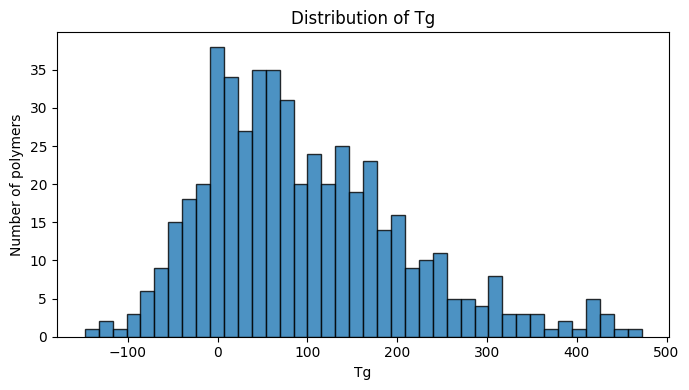

Tg: n=511, min=-148.0297, median=74.0402, max=472.2500
------------------------------------------------------------


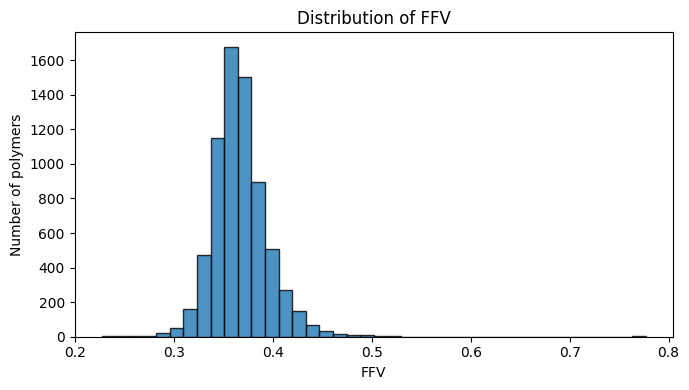

FFV: n=7,030, min=0.2270, median=0.3643, max=0.7771
------------------------------------------------------------


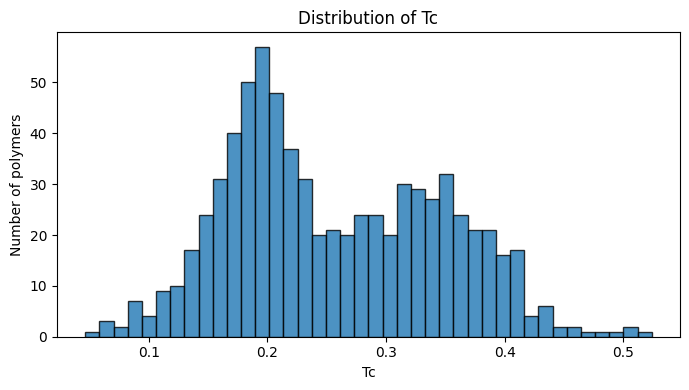

Tc: n=737, min=0.0465, median=0.2360, max=0.5240
------------------------------------------------------------


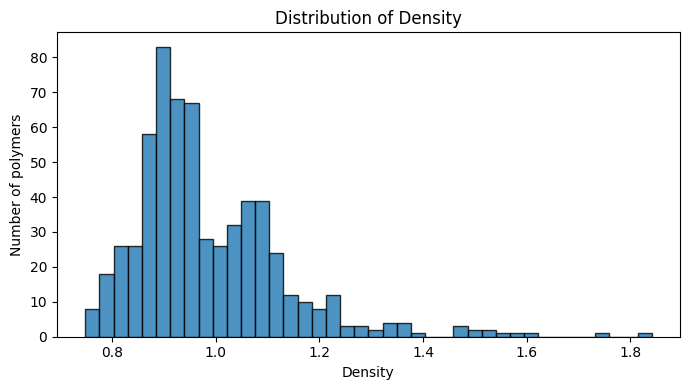

Density: n=613, min=0.7487, median=0.9482, max=1.8410
------------------------------------------------------------


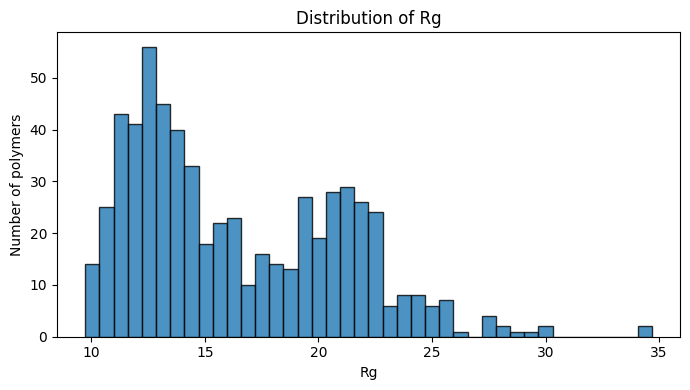

Rg: n=614, min=9.7284, median=15.0522, max=34.6729
------------------------------------------------------------


In [9]:
# Plot each property independently
for target in target_columns:

    values = train[target].dropna()

    plt.figure(figsize=(7, 4))
    plt.hist(values, bins=40, edgecolor="black", alpha=0.8)

    plt.title(f"Distribution of {target}")
    plt.xlabel(target)
    plt.ylabel("Number of polymers")

    plt.tight_layout()
    plt.show()

    print(
        f"{target}: n={len(values):,}, "
        f"min={values.min():.4f}, "
        f"median={values.median():.4f}, "
        f"max={values.max():.4f}"
    )
    print("-" * 60)

## 6. Polymer Structure Validation and Canonicalization

Machine-learning models require consistent representations of polymer chemical structures.

The structures in this dataset are represented as polymer SMILES containing wildcard atoms (`*`). These wildcard atoms denote connection points at the boundaries of the polymer repeat unit and therefore carry important structural information.

Before molecular descriptors or fingerprints are calculated, the polymer representations are evaluated for:

- RDKit parse validity,
- number of polymer connection points,
- disconnected molecular fragments,
- canonicalized representation,
- and structural duplication after canonicalization.

Canonicalization is used only to obtain a consistent representation of equivalent structures. The original SMILES strings are retained unchanged.

In [10]:
!pip -q install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 40.2 MB/s eta 0:00:00


In [11]:
from rdkit import Chem
from rdkit import rdBase

print("RDKit version:", rdBase.rdkitVersion)

RDKit version: 2026.03.6


In [12]:
def analyse_polymer_smiles(smiles):
    """
    Parse a polymer SMILES and return basic structural integrity information.
    """
    try:
        mol = Chem.MolFromSmiles(smiles)

        if mol is None:
            return pd.Series({
                "rdkit_valid": False,
                "canonical_smiles": None,
                "n_connection_points": np.nan,
                "n_fragments": np.nan
            })

        # Wildcard atoms (*) have atomic number 0 in RDKit
        n_connection_points = sum(
            atom.GetAtomicNum() == 0 for atom in mol.GetAtoms()
        )

        n_fragments = len(Chem.GetMolFrags(mol))

        canonical_smiles = Chem.MolToSmiles(
            mol,
            canonical=True
        )

        return pd.Series({
            "rdkit_valid": True,
            "canonical_smiles": canonical_smiles,
            "n_connection_points": n_connection_points,
            "n_fragments": n_fragments
        })

    except Exception:
        return pd.Series({
            "rdkit_valid": False,
            "canonical_smiles": None,
            "n_connection_points": np.nan,
            "n_fragments": np.nan
        })


structure_audit = train["SMILES"].apply(analyse_polymer_smiles)

train = pd.concat([train, structure_audit], axis=1)

print("Polymer structure analysis completed.")

Polymer structure analysis completed.


In [13]:
print("POLYMER STRUCTURE VALIDATION")
print("=" * 55)

print(
    f"RDKit-valid structures:   "
    f"{train['rdkit_valid'].sum():,} / {len(train):,}"
)

print(
    f"Invalid structures:       "
    f"{(~train['rdkit_valid']).sum():,}"
)

print("\nCONNECTION-POINT DISTRIBUTION")
print("-" * 55)

display(
    train.loc[
        train["rdkit_valid"],
        "n_connection_points"
    ]
    .value_counts()
    .sort_index()
    .rename("Number of polymers")
    .to_frame()
)

print("\nFRAGMENT DISTRIBUTION")
print("-" * 55)

display(
    train.loc[
        train["rdkit_valid"],
        "n_fragments"
    ]
    .value_counts()
    .sort_index()
    .rename("Number of polymers")
    .to_frame()
)

POLYMER STRUCTURE VALIDATION
RDKit-valid structures:   7,973 / 7,973
Invalid structures:       0

CONNECTION-POINT DISTRIBUTION
-------------------------------------------------------


,Number of polymers
n_connection_points,
1,2
2,7955
3,8
4,8



FRAGMENT DISTRIBUTION
-------------------------------------------------------


,Number of polymers
n_fragments,
1,7973


In [14]:
valid_structures = train.loc[train["rdkit_valid"]].copy()

n_unique_canonical = valid_structures["canonical_smiles"].nunique()

n_canonical_duplicates = (
    valid_structures["canonical_smiles"].duplicated().sum()
)

print("CANONICAL STRUCTURE CHECK")
print("=" * 55)

print(f"Valid structures:             {len(valid_structures):,}")
print(f"Unique canonical structures:  {n_unique_canonical:,}")
print(f"Canonical duplicate records:  {n_canonical_duplicates:,}")

CANONICAL STRUCTURE CHECK
Valid structures:             7,973
Unique canonical structures:  7,973
Canonical duplicate records:  0


### 6.1 Atypical Polymer Connection-Point Architectures

Most structures contain exactly two wildcard atoms, consistent with a conventional polymer repeat-unit representation.

A small subset contains one, three, or four connection points. These structures are retained initially and examined separately because unusual connection-point counts may represent branched, multifunctional, network-forming, or specially encoded polymer architectures rather than erroneous records.

The objective is to distinguish genuine structural diversity from representation anomalies before any filtering decision is made.

In [15]:
# Identify polymers that do not have the conventional two connection points
atypical_connections = train.loc[
    train["n_connection_points"] != 2,
    [
        "id",
        "SMILES",
        "canonical_smiles",
        "n_connection_points",
        "Tg",
        "FFV",
        "Tc",
        "Density",
        "Rg"
    ]
].copy()

print("ATYPICAL CONNECTION-POINT STRUCTURES")
print("=" * 60)
print(f"Number of records: {len(atypical_connections)}")

display(
    atypical_connections.sort_values(
        "n_connection_points"
    )
)

ATYPICAL CONNECTION-POINT STRUCTURES
Number of records: 18


,id,SMILES,canonical_smiles,n_connection_points,Tg,FFV,Tc,Density,Rg
576,159632571,*Nc1ccc(C2=Cc3ccccc3C3(c4ccccc42)c2cc(C(C)(C)C...,*Nc1ccc(C2=Cc3ccccc3C3(c4ccccc42)c2cc(C(C)(C)C...,1,NaN,0.386494,NaN,NaN,NaN
4836,1308663062,*N[C@@]12C3=CCc4ccccc4[C@]31[C@@]21[C@]2(NC)C3...,*N[C@@]12C3=CCc4ccccc4[C@]31[C@@]21[C@]2(NC)C3...,1,NaN,0.359496,NaN,NaN,NaN
541,150541495,*C=C(*)c1cccc(N2C(=O)c3ccc(C(=O)c4ccc5c(c4)C(=...,*C=C(*)c1cccc(N2C(=O)c3ccc(C(=O)c4ccc5c(c4)C(=...,3,NaN,0.365531,NaN,NaN,NaN
395,109027922,*c1cc(C=Nc2ccc3c(c2)c2cc(N=Cc4cc(*)c(O)c(*)c4)...,*c1cc(C=Nc2ccc3c(c2)c2cc(N=Cc4cc(*)c(O)c(*)c4)...,3,NaN,0.371969,NaN,NaN,NaN
2353,640368237,*C=C(C#N)c1ccc(-c2ccc(C=CC3=CC(=C(C#N)C#N)C=C(...,*C=C(C#N)c1ccc(-c2ccc(C=CC3=CC(=C(C#N)C#N)C=C(...,3,NaN,0.409904,NaN,NaN,NaN
5620,1524213012,*c1cc(C=Nc2ccc3c(c2)c2cc(N=Cc4cc(*)c(O)c(*)c4)...,*c1cc(C=Nc2ccc3c(c2)c2cc(N=Cc4cc(*)c(O)c(*)c4)...,3,NaN,0.369953,NaN,NaN,NaN
4550,1224767743,*OCCON(OCCO*)c1ccc(N=Nc2cc([N+](=O)[O-])ccc2OC...,*OCCON(OCCO*)c1ccc(N=Nc2cc([N+](=O)[O-])ccc2OC...,3,NaN,0.338298,NaN,NaN,NaN
2081,559874694,*Oc1cc(O*)cc(Oc2ccc(C#N)c(*)c2)c1,*Oc1cc(O*)cc(Oc2ccc(C#N)c(*)c2)c1,3,NaN,0.350311,NaN,NaN,NaN
5663,1535630026,*c1cc(C=Nc2ccc3c(c2)c2cc(N=Cc4cc(*)c(O)c(*)c4)...,*c1cc(C=Nc2ccc3c(c2)c2cc(N=Cc4cc(*)c(O)c(*)c4)...,3,NaN,0.376793,NaN,NaN,NaN
6466,1754987570,*OCCCCCCCCCCCOc1ccc2nc(-c3ccc(OCCCCCCCCCCCOC(=...,*OCCCCCCCCCCCOc1ccc2nc(-c3ccc(OCCCCCCCCCCCOC(=...,3,NaN,0.363166,NaN,NaN,NaN


In [16]:
print("TARGET COVERAGE AMONG ATYPICAL STRUCTURES")
print("=" * 60)

atypical_target_summary = pd.DataFrame({
    "Available": atypical_connections[target_columns].notna().sum()
})

atypical_target_summary["% of atypical records"] = (
    atypical_target_summary["Available"]
    / len(atypical_connections)
    * 100
).round(2)

display(atypical_target_summary)

TARGET COVERAGE AMONG ATYPICAL STRUCTURES


,Available,% of atypical records
Tg,0,0.0
FFV,18,100.0
Tc,0,0.0
Density,0,0.0
Rg,0,0.0


## 7. Repeat-Unit Architecture Audit

Polymer SMILES differ from conventional molecular SMILES because wildcard atoms (`*`) denote continuation points of the polymer chain.

Before calculating conventional molecular descriptors, the local bonding environment of these connection points must be examined. This is necessary because directly applying small-molecule descriptors to polymer SMILES containing dummy atoms may produce representations that are difficult to interpret chemically.

This section characterizes:

- connection-point architecture,
- bond types connecting wildcard atoms to the repeat unit,
- repeat-unit heavy-atom count,
- repeat-unit size,
- and structural complexity.

These results will determine how repeat units should be transformed for subsequent descriptor calculation.

In [17]:
def classify_architecture(n_connection_points):
    if n_connection_points == 2:
        return "two_connection_points"
    elif n_connection_points == 1:
        return "one_connection_point"
    elif n_connection_points > 2:
        return "multi_connection_points"
    else:
        return "no_connection_points"


train["architecture_class"] = train[
    "n_connection_points"
].apply(classify_architecture)

print("POLYMER ARCHITECTURE CLASSES")
print("=" * 55)

display(
    train["architecture_class"]
    .value_counts()
    .rename("Number of polymers")
    .to_frame()
)

POLYMER ARCHITECTURE CLASSES


,Number of polymers
architecture_class,
two_connection_points,7955
multi_connection_points,16
one_connection_point,2


In [18]:
from collections import Counter

def get_connection_bond_types(smiles):
    mol = Chem.MolFromSmiles(smiles)

    bond_types = []

    for atom in mol.GetAtoms():
        if atom.GetAtomicNum() == 0:  # wildcard (*)
            for bond in atom.GetBonds():
                bond_types.append(str(bond.GetBondType()))

    return tuple(sorted(bond_types))


train["connection_bond_types"] = train["SMILES"].apply(
    get_connection_bond_types
)

bond_pattern_counts = (
    train["connection_bond_types"]
    .value_counts()
)

print("CONNECTION-POINT BOND PATTERNS")
print("=" * 60)

display(
    bond_pattern_counts
    .rename("Number of polymers")
    .to_frame()
    .head(20)
)

CONNECTION-POINT BOND PATTERNS


,Number of polymers
connection_bond_types,
"(SINGLE, SINGLE)",7940
"(DOUBLE, DOUBLE)",15
"(SINGLE, SINGLE, SINGLE)",8
"(SINGLE, SINGLE, SINGLE, SINGLE, SINGLE)",5
"(SINGLE, SINGLE, SINGLE, SINGLE)",3
"(SINGLE,)",2


In [19]:
def repeat_unit_basic_features(smiles):
    mol = Chem.MolFromSmiles(smiles)

    # Real atoms only; exclude wildcard atoms (*)
    real_atoms = [
        atom for atom in mol.GetAtoms()
        if atom.GetAtomicNum() != 0
    ]

    heavy_atoms = len(real_atoms)

    heteroatoms = sum(
        atom.GetAtomicNum() not in (1, 6)
        for atom in real_atoms
    )

    aromatic_atoms = sum(
        atom.GetIsAromatic()
        for atom in real_atoms
    )

    rings = mol.GetRingInfo().NumRings()

    return pd.Series({
        "repeat_heavy_atoms": heavy_atoms,
        "repeat_heteroatoms": heteroatoms,
        "repeat_aromatic_atoms": aromatic_atoms,
        "repeat_ring_count": rings
    })


basic_features = train["SMILES"].apply(
    repeat_unit_basic_features
)

train = pd.concat(
    [train, basic_features],
    axis=1
)

print("BASIC REPEAT-UNIT STRUCTURAL SUMMARY")
print("=" * 60)

display(
    train[
        [
            "repeat_heavy_atoms",
            "repeat_heteroatoms",
            "repeat_aromatic_atoms",
            "repeat_ring_count"
        ]
    ]
    .describe()
    .T
    .round(3)
)

BASIC REPEAT-UNIT STRUCTURAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
repeat_heavy_atoms,7973.0,32.292,17.954,1.0,18.0,29.0,43.0,164.0
repeat_heteroatoms,7973.0,6.232,4.598,0.0,3.0,5.0,8.0,52.0
repeat_aromatic_atoms,7973.0,17.623,15.116,0.0,6.0,16.0,24.0,96.0
repeat_ring_count,7973.0,3.675,3.081,0.0,1.0,3.0,6.0,18.0


## 8. Polymer-Specific Interpretable Structural Descriptors

Conventional molecular descriptors are typically designed for discrete, closed-shell small molecules. Polymer repeat-unit SMILES differ because wildcard atoms (`*`) encode continuation of the macromolecular chain.

Rather than immediately converting these connection points into artificial terminal atoms, this analysis first constructs descriptors directly from the repeat-unit graph while excluding wildcard atoms from elemental counts.

The descriptors quantify chemically interpretable characteristics including:

- repeat-unit size,
- elemental composition,
- heteroatom content,
- aromatic character,
- ring content,
- carbonyl functionality,
- halogen content,
- heteroatom fractions,
- and aromatic fraction.

These features form the first interpretable representation of polymer chemical space.

In [20]:
def polymer_interpretable_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)

    # Real atoms only: exclude polymer wildcard atoms (*)
    atoms = [
        atom for atom in mol.GetAtoms()
        if atom.GetAtomicNum() != 0
    ]

    n_atoms = len(atoms)

    # Element counts
    n_C = sum(atom.GetAtomicNum() == 6 for atom in atoms)
    n_N = sum(atom.GetAtomicNum() == 7 for atom in atoms)
    n_O = sum(atom.GetAtomicNum() == 8 for atom in atoms)
    n_S = sum(atom.GetAtomicNum() == 16 for atom in atoms)

    n_halogen = sum(
        atom.GetAtomicNum() in (9, 17, 35, 53)
        for atom in atoms
    )

    n_hetero = sum(
        atom.GetAtomicNum() not in (1, 6)
        for atom in atoms
    )

    n_aromatic = sum(
        atom.GetIsAromatic()
        for atom in atoms
    )

    # Ring count
    n_rings = mol.GetRingInfo().NumRings()

    # Fractions normalize composition by repeat-unit size
    hetero_fraction = (
        n_hetero / n_atoms if n_atoms > 0 else np.nan
    )

    aromatic_fraction = (
        n_aromatic / n_atoms if n_atoms > 0 else np.nan
    )

    carbon_fraction = (
        n_C / n_atoms if n_atoms > 0 else np.nan
    )

    return pd.Series({
        "n_atoms": n_atoms,
        "n_C": n_C,
        "n_N": n_N,
        "n_O": n_O,
        "n_S": n_S,
        "n_halogen": n_halogen,
        "n_hetero": n_hetero,
        "n_aromatic": n_aromatic,
        "n_rings": n_rings,
        "hetero_fraction": hetero_fraction,
        "aromatic_fraction": aromatic_fraction,
        "carbon_fraction": carbon_fraction
    })


interpretable_desc = train["SMILES"].apply(
    polymer_interpretable_descriptors
)

train = pd.concat(
    [train, interpretable_desc],
    axis=1
)

print("Interpretable polymer descriptors generated.")

Interpretable polymer descriptors generated.


In [21]:
descriptor_columns = [
    "n_atoms",
    "n_C",
    "n_N",
    "n_O",
    "n_S",
    "n_halogen",
    "n_hetero",
    "n_aromatic",
    "n_rings",
    "hetero_fraction",
    "aromatic_fraction",
    "carbon_fraction"
]

print("INTERPRETABLE DESCRIPTOR SUMMARY")
print("=" * 65)

display(
    train[descriptor_columns]
    .describe()
    .T
    .round(4)
)

INTERPRETABLE DESCRIPTOR SUMMARY


,count,mean,std,min,25%,50%,75%,max
n_atoms,7973.0,32.2921,17.9536,1.0,18.000,29.0000,43.0000,164.0
n_C,7973.0,26.0480,15.1579,0.0,14.000,24.0000,35.0000,133.0
n_N,7973.0,1.6484,1.6642,0.0,0.000,2.0000,2.0000,14.0
n_O,7973.0,3.5095,2.9389,0.0,1.000,3.0000,6.0000,38.0
n_S,7973.0,0.1809,0.5758,0.0,0.000,0.0000,0.0000,10.0
n_halogen,7973.0,0.7831,2.5965,0.0,0.000,0.0000,0.0000,36.0
n_hetero,7973.0,6.2320,4.5978,0.0,3.000,5.0000,8.0000,52.0
n_aromatic,7973.0,17.6230,15.1157,0.0,6.000,16.0000,24.0000,96.0
n_rings,7973.0,3.6747,3.0811,0.0,1.000,3.0000,6.0000,18.0
hetero_fraction,7973.0,0.2008,0.1150,0.0,0.125,0.1905,0.2500,1.0


### 8.1 Elemental Diversity of Polymer Chemical Space

The prevalence of major heteroatoms provides an initial description of the chemical diversity represented in the dataset.

Both absolute counts and polymer-level occurrence are useful. A polymer may contain many atoms of one element, while another element may occur only once but across a large fraction of the dataset.

Here, elemental occurrence refers to whether a repeat unit contains at least one atom of the corresponding element.

In [22]:
element_presence = pd.DataFrame({
    "Nitrogen-containing": (train["n_N"] > 0).sum(),
    "Oxygen-containing": (train["n_O"] > 0).sum(),
    "Sulfur-containing": (train["n_S"] > 0).sum(),
    "Halogen-containing": (train["n_halogen"] > 0).sum(),
    "Aromatic-containing": (train["n_aromatic"] > 0).sum(),
}, index=["Number of polymers"]).T

element_presence["Percentage (%)"] = (
    element_presence["Number of polymers"]
    / len(train)
    * 100
).round(2)

print("POLYMER CHEMICAL-FEATURE PREVALENCE")
print("=" * 65)

display(element_presence)

POLYMER CHEMICAL-FEATURE PREVALENCE


,Number of polymers,Percentage (%)
Nitrogen-containing,5229,65.58
Oxygen-containing,6249,78.38
Sulfur-containing,982,12.32
Halogen-containing,1062,13.32
Aromatic-containing,6350,79.64


## 9. Functional-Group Mapping of Polymer Repeat Units

Elemental composition alone does not fully describe polymer chemistry. Atoms of the same element may participate in chemically distinct functional groups with substantially different effects on polarity, rigidity, intermolecular interactions, and material properties.

To obtain a more chemically interpretable representation of polymer space, common functional motifs are identified using SMARTS substructure patterns.

The initial functional-group atlas includes:

- carbonyl groups,
- ester groups,
- amide groups,
- ether linkages,
- hydroxyl groups,
- nitrile groups,
- sulfone groups,
- aromatic rings,
- fluorinated motifs,
- and carbon–carbon double bonds.

These descriptors provide a bridge between molecular representation and recognizable polymer chemistry.

In [23]:
# SMARTS definitions for chemically interpretable polymer motifs

functional_group_smarts = {
    "carbonyl": "[CX3]=[OX1]",
    "ester": "[CX3](=[OX1])[OX2]",
    "amide": "[NX3][CX3](=[OX1])",
    "ether": "[OD2]([#6])[#6]",
    "hydroxyl": "[OX2H]",
    "nitrile": "[CX2]#N",
    "sulfone": "[SX4](=[OX1])(=[OX1])",
    "c_c_double_bond": "[#6]=[#6]",
    "c_f_bond": "[#6]-[F]"
}

functional_group_patterns = {
    name: Chem.MolFromSmarts(smarts)
    for name, smarts in functional_group_smarts.items()
}

print("FUNCTIONAL-GROUP SMARTS PATTERNS")
print("=" * 65)

for name, pattern in functional_group_patterns.items():
    print(f"{name:20s} -> valid pattern: {pattern is not None}")

FUNCTIONAL-GROUP SMARTS PATTERNS
carbonyl             -> valid pattern: True
ester                -> valid pattern: True
amide                -> valid pattern: True
ether                -> valid pattern: True
hydroxyl             -> valid pattern: True
nitrile              -> valid pattern: True
sulfone              -> valid pattern: True
c_c_double_bond      -> valid pattern: True
c_f_bond             -> valid pattern: True


In [24]:
def count_functional_groups(smiles):
    mol = Chem.MolFromSmiles(smiles)

    counts = {}

    for name, pattern in functional_group_patterns.items():
        matches = mol.GetSubstructMatches(pattern)
        counts[f"fg_{name}"] = len(matches)

    return pd.Series(counts)


functional_group_counts = train["SMILES"].apply(
    count_functional_groups
)

train = pd.concat(
    [train, functional_group_counts],
    axis=1
)

fg_columns = list(functional_group_counts.columns)

print("Functional-group descriptors generated.")
print(f"Number of functional-group descriptors: {len(fg_columns)}")

Functional-group descriptors generated.
Number of functional-group descriptors: 9


In [25]:
functional_group_prevalence = pd.DataFrame({
    "Polymers containing group": [
        (train[column] > 0).sum()
        for column in fg_columns
    ]
}, index=fg_columns)

functional_group_prevalence["Percentage (%)"] = (
    functional_group_prevalence["Polymers containing group"]
    / len(train)
    * 100
).round(2)

functional_group_prevalence = (
    functional_group_prevalence
    .sort_values(
        "Polymers containing group",
        ascending=False
    )
)

print("FUNCTIONAL-GROUP PREVALENCE")
print("=" * 65)

display(functional_group_prevalence)

FUNCTIONAL-GROUP PREVALENCE


,Polymers containing group,Percentage (%)
fg_carbonyl,5005,62.77
fg_ether,4262,53.46
fg_amide,2881,36.13
fg_ester,2403,30.14
fg_c_c_double_bond,821,10.30
fg_c_f_bond,818,10.26
fg_sulfone,477,5.98
fg_hydroxyl,307,3.85
fg_nitrile,262,3.29


In [26]:
# Explicit heavy-atom count: exclude wildcard atoms and hydrogen
train["n_heavy_atoms"] = train["SMILES"].apply(
    lambda smiles: sum(
        atom.GetAtomicNum() > 1
        for atom in Chem.MolFromSmiles(smiles).GetAtoms()
    )
)

difference = (
    train["n_atoms"] != train["n_heavy_atoms"]
).sum()

print(
    "Records where n_atoms differs from "
    f"n_heavy_atoms: {difference:,}"
)

Records where n_atoms differs from n_heavy_atoms: 14


## 10. Descriptor Definition Refinement

A small subset of polymer representations contains explicit hydrogen atoms.

Because polymer size and compositional fractions should be based on heavy atoms rather than hydrogen atoms, heavy-atom counts are explicitly defined as atoms with atomic number greater than one.

The occurrence of explicit hydrogens is first audited, after which size-normalized compositional descriptors are recalculated using heavy atoms as the denominator.

This refinement ensures that descriptor definitions remain chemically consistent across all polymer records.

In [27]:
def count_explicit_hydrogens(smiles):
    mol = Chem.MolFromSmiles(smiles)

    return sum(
        atom.GetAtomicNum() == 1
        for atom in mol.GetAtoms()
    )


train["n_explicit_H"] = train["SMILES"].apply(
    count_explicit_hydrogens
)

explicit_h_records = train.loc[
    train["n_explicit_H"] > 0,
    [
        "id",
        "SMILES",
        "n_explicit_H",
        "n_atoms",
        "n_heavy_atoms",
        "Tg",
        "FFV",
        "Tc",
        "Density",
        "Rg"
    ]
].copy()

print("EXPLICIT-HYDROGEN AUDIT")
print("=" * 65)

print(
    f"Polymers containing explicit H atoms: "
    f"{len(explicit_h_records):,}"
)

print(
    f"Maximum explicit H atoms in one representation: "
    f"{train['n_explicit_H'].max()}"
)

display(explicit_h_records)

EXPLICIT-HYDROGEN AUDIT
Polymers containing explicit H atoms: 14
Maximum explicit H atoms in one representation: 22


,id,SMILES,n_explicit_H,n_atoms,n_heavy_atoms,Tg,FFV,Tc,Density,Rg
70,18339242,*CC(*)C(=O)OC([2H])([2H])[2H],3,9.0,6,NaN,0.327140,NaN,NaN,NaN
1765,475921569,*CC(*)c1c([2H])c([2H])c([2H])c([2H])c1[2H],5,13.0,8,NaN,0.393691,NaN,0.923679,14.830815
2435,666199912,*C([2H])([2H])C(*)([2H])C([2H])([2H])[2H],6,9.0,3,NaN,0.386143,NaN,NaN,NaN
4130,1116322713,*C([2H])([2H])C(*)(C(=O)OC([2H])([2H])C([2H])(...,10,18.0,8,NaN,0.355237,NaN,NaN,NaN
4290,1156532186,*C([2H])([2H])C(*)([2H])c1c([2H])c([2H])c([2H]...,8,16.0,8,NaN,0.388447,0.199,0.938617,15.867353
5390,1463175891,*C([2H])([2H])C(*)(C([2H])([2H])[2H])C([2H])([...,8,12.0,4,85.267110,NaN,NaN,NaN,NaN
6045,1639677802,*C([2H])([2H])C(*)(C(=O)OC([2H])([2H])[2H])C([...,8,15.0,7,NaN,0.337617,NaN,NaN,NaN
6249,1696155039,*C([2H])([2H])C(*)([2H])Cl,3,6.0,3,NaN,0.373871,NaN,NaN,NaN
6427,1743216271,*Oc1c([2H])c([2H])c(S(=O)(=O)c2c([2H])c([2H])c...,22,54.0,32,NaN,0.379340,NaN,NaN,NaN
6501,1766008027,*Nc1c([2H])c([2H])c(*)c([2H])c1[2H],4,11.0,7,235.370823,NaN,NaN,NaN,NaN


In [28]:
# Recalculate composition fractions using heavy atoms only

train["hetero_fraction"] = (
    train["n_hetero"] / train["n_heavy_atoms"]
)

train["aromatic_fraction"] = (
    train["n_aromatic"] / train["n_heavy_atoms"]
)

train["carbon_fraction"] = (
    train["n_C"] / train["n_heavy_atoms"]
)

print("CORRECTED HEAVY-ATOM-NORMALIZED FRACTIONS")
print("=" * 65)

display(
    train[
        [
            "n_heavy_atoms",
            "hetero_fraction",
            "aromatic_fraction",
            "carbon_fraction"
        ]
    ]
    .describe()
    .T
    .round(4)
)

CORRECTED HEAVY-ATOM-NORMALIZED FRACTIONS


,count,mean,std,min,25%,50%,75%,max
n_heavy_atoms,7973.0,32.2801,17.9638,1.0,18.000,29.0000,43.0000,164.0
hetero_fraction,7973.0,0.2009,0.1150,0.0,0.125,0.1905,0.2500,1.0
aromatic_fraction,7973.0,0.4740,0.2943,0.0,0.300,0.5217,0.7045,1.0
carbon_fraction,7973.0,0.7991,0.1150,0.0,0.750,0.8095,0.8750,1.0


## 11. Refined Functional-Group Definitions

The initial SMARTS screening demonstrated that common functional motifs are widespread throughout the polymer dataset.

Before these descriptors are used for chemical-space analysis, the SMARTS definitions are refined to reduce ambiguity between overlapping chemical environments.

In particular:

- ester oxygen is distinguished from generic ether oxygen,
- ether linkages exclude oxygen directly attached to carbonyl carbon,
- sulfone is restricted to carbon-substituted sulfonyl motifs,
- and functional-group descriptors are treated as overlapping chemical features rather than mutually exclusive polymer classes.

A polymer may therefore contain several functional groups simultaneously.

In [29]:
refined_functional_group_smarts = {
    # General C=O functionality
    "carbonyl": "[CX3]=[OX1]",

    # Ester: C(=O)-O-C, excluding carboxylic-acid OH
    "ester": "[CX3](=[OX1])[OX2H0][#6]",

    # Amide-like carbonyl attached to nitrogen
    "amide": "[CX3](=[OX1])[NX3]",

    # Ether oxygen bonded to two carbons,
    # excluding carbonyl-adjacent carbons
    "ether": (
        "[OD2;H0]"
        "([#6;!$([CX3]=[OX1])])"
        "[#6;!$([CX3]=[OX1])]"
    ),

    # Alcoholic/phenolic/carboxylic hydroxyl motif
    "hydroxyl": "[OX2H]",

    # Nitrile
    "nitrile": "[CX2]#N",

    # Carbon-substituted sulfone
    "sulfone": "[#6][SX4](=[OX1])(=[OX1])[#6]",

    # Carbon-carbon double bond
    "c_c_double_bond": "[#6]=[#6]",

    # Carbon-fluorine bond
    "c_f_bond": "[#6][F]"
}


refined_patterns = {
    name: Chem.MolFromSmarts(smarts)
    for name, smarts
    in refined_functional_group_smarts.items()
}

print("REFINED FUNCTIONAL-GROUP SMARTS")
print("=" * 65)

for name, pattern in refined_patterns.items():
    print(
        f"{name:20s} -> "
        f"valid pattern: {pattern is not None}"
    )

REFINED FUNCTIONAL-GROUP SMARTS
carbonyl             -> valid pattern: True
ester                -> valid pattern: True
amide                -> valid pattern: True
ether                -> valid pattern: True
hydroxyl             -> valid pattern: True
nitrile              -> valid pattern: True
sulfone              -> valid pattern: True
c_c_double_bond      -> valid pattern: True
c_f_bond             -> valid pattern: True


In [30]:
def count_refined_functional_groups(smiles):
    mol = Chem.MolFromSmiles(smiles)

    counts = {}

    for name, pattern in refined_patterns.items():
        matches = mol.GetSubstructMatches(
            pattern,
            uniquify=True
        )

        counts[f"fg_{name}"] = len(matches)

    return pd.Series(counts)


refined_fg_counts = train["SMILES"].apply(
    count_refined_functional_groups
)

# Overwrite the preliminary functional-group columns
# rather than creating duplicate column names
for column in refined_fg_counts.columns:
    train[column] = refined_fg_counts[column]

fg_columns = list(refined_fg_counts.columns)

print(
    "Refined functional-group descriptors generated."
)

Refined functional-group descriptors generated.


In [31]:
functional_group_prevalence = pd.DataFrame({
    "Polymers containing group": [
        (train[column] > 0).sum()
        for column in fg_columns
    ]
}, index=fg_columns)

functional_group_prevalence["Percentage (%)"] = (
    functional_group_prevalence[
        "Polymers containing group"
    ]
    / len(train)
    * 100
).round(2)

functional_group_prevalence = (
    functional_group_prevalence
    .sort_values(
        "Polymers containing group",
        ascending=False
    )
)

print("REFINED FUNCTIONAL-GROUP PREVALENCE")
print("=" * 65)

display(functional_group_prevalence)

REFINED FUNCTIONAL-GROUP PREVALENCE


,Polymers containing group,Percentage (%)
fg_carbonyl,5005,62.77
fg_amide,2881,36.13
fg_ether,2727,34.20
fg_ester,2314,29.02
fg_c_c_double_bond,821,10.30
fg_c_f_bond,818,10.26
fg_sulfone,362,4.54
fg_hydroxyl,307,3.85
fg_nitrile,262,3.29


## 12. Chemical-Space Composition Across Property Datasets

The five target properties are not measured for the same set of polymers.

Consequently, each property-specific modelling dataset may occupy a different region of polymer chemical space. Differences in model performance could therefore reflect differences in chemical composition, structural complexity, or dataset coverage rather than property predictability alone.

This section compares the structural characteristics of the polymer subsets associated with Tg, FFV, Tc, Density, and Rg.

The analysis focuses on:

- repeat-unit size,
- heteroatom fraction,
- aromatic fraction,
- ring content,
- elemental composition,
- and functional-group prevalence.

These comparisons provide an initial assessment of dataset shift between property-specific polymer populations.

In [32]:
# Interpretable structural features used to compare target-specific datasets
chemical_space_features = [
    "n_heavy_atoms",
    "hetero_fraction",
    "aromatic_fraction",
    "n_rings",
    "n_N",
    "n_O",
    "n_S",
    "n_halogen"
]

target_chemical_summary = []

for target in target_columns:

    subset = train.loc[
        train[target].notna()
    ]

    row = {
        "Target": target,
        "n_polymers": len(subset)
    }

    for feature in chemical_space_features:
        row[f"{feature}_median"] = subset[feature].median()

    target_chemical_summary.append(row)


target_chemical_summary = pd.DataFrame(
    target_chemical_summary
).set_index("Target")

print("TARGET-SPECIFIC CHEMICAL-SPACE SUMMARY")
print("=" * 70)

display(
    target_chemical_summary.round(4)
)

TARGET-SPECIFIC CHEMICAL-SPACE SUMMARY


,n_polymers,n_heavy_atoms_median,hetero_fraction_median,aromatic_fraction_median,n_rings_median,n_N_median,n_O_median,n_S_median,n_halogen_median
Target,,,,,,,,,
Tg,511,24.0,0.2222,0.4286,2.0,1.0,3.0,0.0,0.0
FFV,7030,31.0,0.1915,0.5455,3.0,2.0,4.0,0.0,0.0
Tc,737,16.0,0.1429,0.0000,0.0,0.0,2.0,0.0,0.0
Density,613,16.0,0.1481,0.0000,0.0,0.0,2.0,0.0,0.0
Rg,614,16.0,0.1481,0.0000,0.0,0.0,2.0,0.0,0.0


In [33]:
target_fg_prevalence = pd.DataFrame(
    index=target_columns,
    columns=fg_columns,
    dtype=float
)

for target in target_columns:

    subset = train.loc[
        train[target].notna()
    ]

    for fg in fg_columns:

        target_fg_prevalence.loc[target, fg] = (
            (subset[fg] > 0).mean() * 100
        )


# Shorter labels for readability
target_fg_prevalence.columns = [
    column.replace("fg_", "")
    for column in target_fg_prevalence.columns
]

print("FUNCTIONAL-GROUP PREVALENCE BY TARGET (%)")
print("=" * 70)

display(
    target_fg_prevalence.round(2)
)

FUNCTIONAL-GROUP PREVALENCE BY TARGET (%)


,carbonyl,ester,amide,ether,hydroxyl,nitrile,sulfone,c_c_double_bond,c_f_bond
Tg,67.51,32.68,37.18,23.68,5.48,1.57,2.74,14.29,5.09
FFV,63.13,28.83,36.80,36.26,3.84,3.56,4.91,9.80,10.90
Tc,59.84,35.69,23.74,13.57,2.17,2.99,0.95,7.33,5.29
Density,58.73,36.05,20.55,14.19,3.10,3.92,2.12,7.67,5.22
Rg,58.47,35.50,20.36,14.17,3.09,3.91,2.12,7.65,5.21


### 12.1 Functional-Group Composition Across Target Subsets

Functional-group prevalence is compared across the five property-specific datasets.

Large differences indicate that target datasets sample different polymer chemistries. Such differences are important when interpreting predictive performance and when considering transfer learning or multi-property modelling.

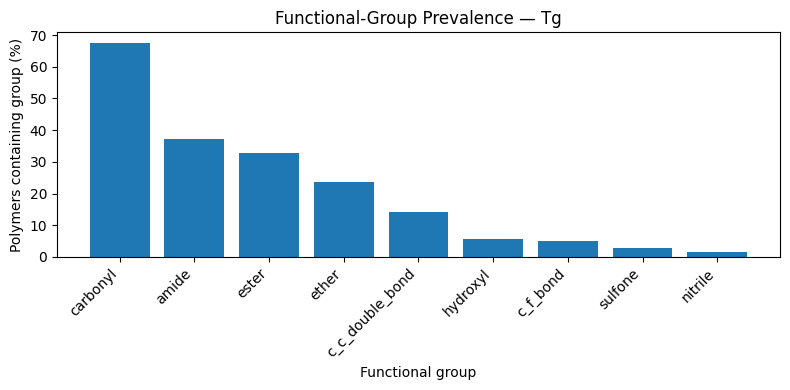

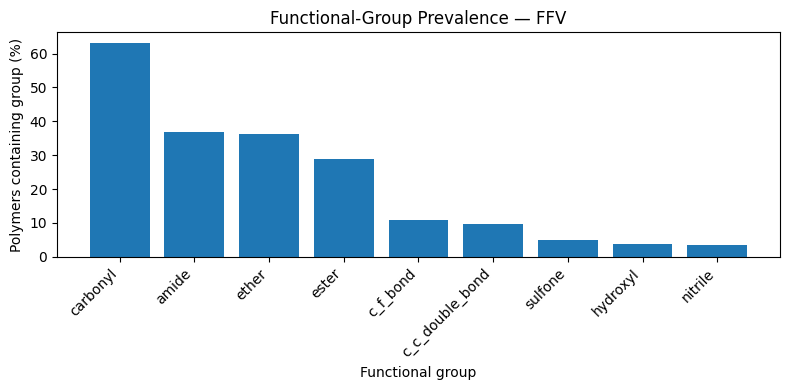

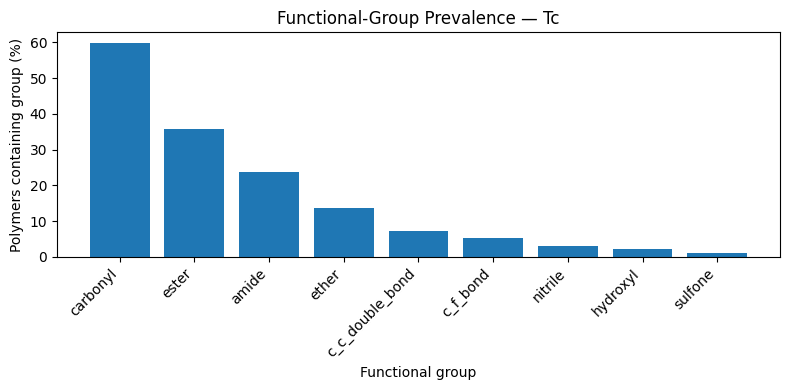

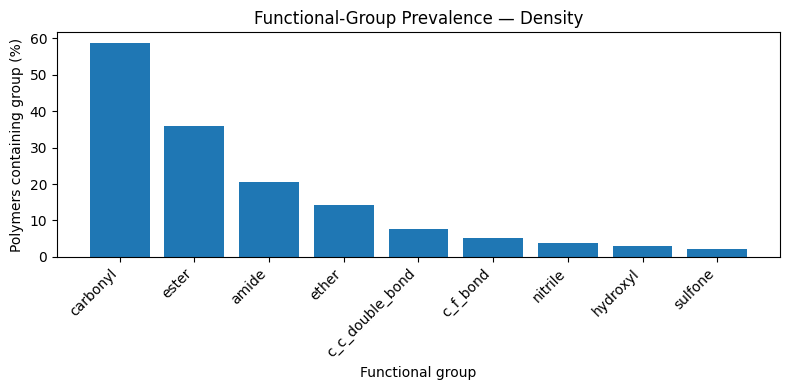

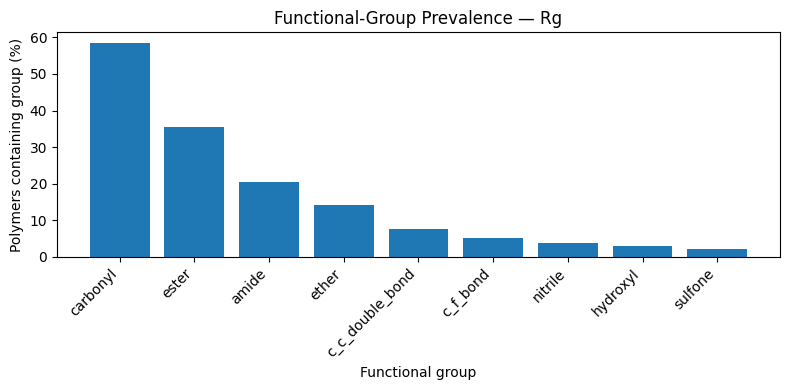

In [34]:
# Plot one target at a time for readability

for target in target_columns:

    values = (
        target_fg_prevalence
        .loc[target]
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(8, 4))

    plt.bar(
        values.index,
        values.values
    )

    plt.title(
        f"Functional-Group Prevalence — {target}"
    )

    plt.ylabel(
        "Polymers containing group (%)"
    )

    plt.xlabel(
        "Functional group"
    )

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.tight_layout()
    plt.show()

In [35]:
def aromaticity_class(value):
    if value == 0:
        return "non_aromatic"
    elif value < 0.5:
        return "partly_aromatic"
    else:
        return "aromatic_rich"


train["aromaticity_class"] = train[
    "aromatic_fraction"
].apply(aromaticity_class)


aromaticity_by_target = {}

for target in target_columns:

    subset = train.loc[
        train[target].notna()
    ]

    percentages = (
        subset["aromaticity_class"]
        .value_counts(normalize=True)
        .mul(100)
    )

    aromaticity_by_target[target] = percentages


aromaticity_by_target = (
    pd.DataFrame(aromaticity_by_target)
    .T
    .fillna(0)
)

print("AROMATICITY CLASS BY TARGET (%)")
print("=" * 70)

display(
    aromaticity_by_target.round(2)
)

AROMATICITY CLASS BY TARGET (%)


aromaticity_class,aromatic_rich,non_aromatic,partly_aromatic
Tg,43.64,27.59,28.77
FFV,57.64,16.94,25.42
Tc,17.50,62.96,19.54
Density,23.16,58.40,18.43
Rg,22.96,58.79,18.24


## 13. Target-Domain Membership and Dataset Overlap

The chemical-space analysis indicates substantial differences among the property-specific datasets.

However, several target subsets also share many of the same polymer records, particularly thermal conductivity, density, and radius of gyration.

To distinguish true chemical similarity from similarity caused by overlapping records, target membership is analysed explicitly.

This section quantifies:

- pairwise shared polymers,
- union sizes,
- Jaccard similarity between target datasets,
- and the exact combinations of target properties available for each polymer.

The results will determine whether property datasets should be treated as independent populations or as partially shared domains.

In [36]:
# Boolean target-membership matrix
target_membership = train[target_columns].notna()

# Pairwise Jaccard similarity
jaccard_matrix = pd.DataFrame(
    index=target_columns,
    columns=target_columns,
    dtype=float
)

for target_a in target_columns:
    for target_b in target_columns:

        intersection = (
            target_membership[target_a]
            & target_membership[target_b]
        ).sum()

        union = (
            target_membership[target_a]
            | target_membership[target_b]
        ).sum()

        jaccard_matrix.loc[target_a, target_b] = (
            intersection / union
        )

print("PAIRWISE TARGET-DATASET JACCARD SIMILARITY")
print("=" * 65)

display(
    (jaccard_matrix * 100).round(2)
)

PAIRWISE TARGET-DATASET JACCARD SIMILARITY


,Tg,FFV,Tc,Density,Rg
Tg,100.00,0.01,2.63,2.18,2.18
FFV,0.01,100.00,4.02,3.66,3.66
Tc,2.63,4.02,100.00,64.84,65.56
Density,2.18,3.66,64.84,100.00,98.87
Rg,2.18,3.66,65.56,98.87,100.00


In [37]:
def target_signature(row):
    available = [
        target
        for target in target_columns
        if pd.notna(row[target])
    ]

    return " + ".join(available)


train["target_signature"] = train.apply(
    target_signature,
    axis=1
)

target_signature_counts = (
    train["target_signature"]
    .value_counts()
    .rename("Number of polymers")
    .to_frame()
)

target_signature_counts["Percentage (%)"] = (
    target_signature_counts["Number of polymers"]
    / len(train)
    * 100
).round(2)

print("EXACT TARGET-AVAILABILITY COMBINATIONS")
print("=" * 70)

display(target_signature_counts)

EXACT TARGET-AVAILABILITY COMBINATIONS


,Number of polymers,Percentage (%)
target_signature,,
FFV,6681,83.80
Tg,473,5.93
Tc + Density + Rg,292,3.66
FFV + Tc + Density + Rg,221,2.77
Tc,110,1.38
FFV + Tc,78,0.98
FFV + Density + Rg,47,0.59
Density + Rg,26,0.33
Tg + Tc + Density + Rg,18,0.23


In [38]:
tdr_targets = ["Tc", "Density", "Rg"]

all_three_mask = (
    train[tdr_targets]
    .notna()
    .all(axis=1)
)

n_all_three = all_three_mask.sum()

print("Tc–DENSITY–Rg SHARED BLOCK")
print("=" * 60)

print(
    f"Polymers containing all three targets: "
    f"{n_all_three:,}"
)

for target in tdr_targets:

    n_target = train[target].notna().sum()

    percentage = (
        n_all_three / n_target * 100
    )

    print(
        f"{percentage:.2f}% of {target} records "
        f"belong to the complete Tc–Density–Rg block."
    )

Tc–DENSITY–Rg SHARED BLOCK
Polymers containing all three targets: 531
72.05% of Tc records belong to the complete Tc–Density–Rg block.
86.62% of Density records belong to the complete Tc–Density–Rg block.
86.48% of Rg records belong to the complete Tc–Density–Rg block.


## 14. Interpretable Polymer Chemical-Space Mapping

The preceding analysis demonstrated that the five property datasets differ substantially in both record overlap and chemical composition.

To visualize these relationships within a common structural reference frame, an interpretable polymer chemical-space representation is constructed using principal component analysis (PCA).

Raw structural counts are not used directly for all descriptors because larger repeat units naturally contain more atoms, rings, and functional groups. Such size dependence could cause the resulting chemical-space map to primarily represent repeat-unit length rather than chemical composition.

Therefore, the PCA representation combines:

- one explicit repeat-unit size descriptor,
- normalized elemental composition,
- aromatic and heteroatom fractions,
- ring density,
- and size-normalized functional-group descriptors.

All polymers are projected into the same PCA coordinate system before property-specific subsets are examined. This allows differences among Tg, FFV, Tc, Density, and Rg datasets to be interpreted relative to a common polymer chemical space.

In [39]:
# ============================================================
# Construct normalized chemical-space descriptors
# ============================================================

# Elemental fractions relative to repeat-unit heavy atoms
train["N_fraction"] = train["n_N"] / train["n_heavy_atoms"]
train["O_fraction"] = train["n_O"] / train["n_heavy_atoms"]
train["S_fraction"] = train["n_S"] / train["n_heavy_atoms"]
train["halogen_fraction"] = (
    train["n_halogen"] / train["n_heavy_atoms"]
)

# Ring density
train["ring_density"] = (
    train["n_rings"] / train["n_heavy_atoms"]
)

# Functional-group densities
for fg in fg_columns:
    density_name = fg.replace("fg_", "density_")

    train[density_name] = (
        train[fg] / train["n_heavy_atoms"]
    )

print("Normalized chemical-space descriptors generated.")

Normalized chemical-space descriptors generated.


In [40]:
# ============================================================
# Final interpretable feature set for PCA
# ============================================================

pca_features = [
    # Absolute structural size
    "n_heavy_atoms",

    # Overall composition
    "hetero_fraction",
    "aromatic_fraction",
    "N_fraction",
    "O_fraction",
    "S_fraction",
    "halogen_fraction",

    # Ring structure
    "ring_density",

    # Functional-group densities
    "density_carbonyl",
    "density_ester",
    "density_amide",
    "density_ether",
    "density_hydroxyl",
    "density_nitrile",
    "density_sulfone",
    "density_c_c_double_bond",
    "density_c_f_bond"
]

print("PCA FEATURE SET")
print("=" * 60)

print(f"Number of descriptors: {len(pca_features)}")

for feature in pca_features:
    print(f"  - {feature}")

PCA FEATURE SET
Number of descriptors: 17
  - n_heavy_atoms
  - hetero_fraction
  - aromatic_fraction
  - N_fraction
  - O_fraction
  - S_fraction
  - halogen_fraction
  - ring_density
  - density_carbonyl
  - density_ester
  - density_amide
  - density_ether
  - density_hydroxyl
  - density_nitrile
  - density_sulfone
  - density_c_c_double_bond
  - density_c_f_bond


In [41]:
# ============================================================
# PCA input integrity check
# ============================================================

pca_input = train[pca_features].copy()

print("PCA INPUT INTEGRITY")
print("=" * 60)

print(
    f"Missing values: "
    f"{pca_input.isna().sum().sum():,}"
)

print(
    f"Infinite values: "
    f"{np.isinf(pca_input.to_numpy()).sum():,}"
)

print(
    f"Polymers: "
    f"{len(pca_input):,}"
)

print(
    f"Features: "
    f"{pca_input.shape[1]}"
)

PCA INPUT INTEGRITY
Missing values: 0
Infinite values: 0
Polymers: 7,973
Features: 17


### 14.1 Descriptor Standardization

The chemical-space descriptors have substantially different numerical scales.

For example, repeat-unit size may vary from approximately 1 to more than 100 heavy atoms, whereas elemental fractions lie between 0 and 1.

PCA is sensitive to variable scale because it identifies directions of maximum variance. Without standardization, descriptors with numerically larger ranges could dominate the principal components regardless of their chemical importance.

Each descriptor is therefore standardized to zero mean and unit variance before PCA.

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    pca_input
)

print("STANDARDIZED PCA MATRIX")
print("=" * 60)

print("Shape:", X_scaled.shape)

print(
    "Approximate overall mean:",
    round(X_scaled.mean(), 6)
)

print(
    "Approximate overall standard deviation:",
    round(X_scaled.std(), 6)
)

STANDARDIZED PCA MATRIX
Shape: (7973, 17)
Approximate overall mean: 0.0
Approximate overall standard deviation: 1.0


In [43]:
from sklearn.decomposition import PCA

# Fit PCA to all interpretable polymer descriptors
pca = PCA()

X_pca_all = pca.fit_transform(
    X_scaled
)

explained_variance = (
    pca.explained_variance_ratio_ * 100
)

cumulative_variance = np.cumsum(
    explained_variance
)

variance_table = pd.DataFrame({
    "Principal Component": [
        f"PC{i + 1}"
        for i in range(len(explained_variance))
    ],
    "Explained Variance (%)":
        explained_variance,
    "Cumulative Variance (%)":
        cumulative_variance
})

print("PCA EXPLAINED VARIANCE")
print("=" * 60)

display(
    variance_table.head(10).round(2)
)

PCA EXPLAINED VARIANCE


,Principal Component,Explained Variance (%),Cumulative Variance (%)
0,PC1,20.44,20.44
1,PC2,13.46,33.90
2,PC3,11.52,45.42
3,PC4,9.10,54.52
4,PC5,7.86,62.38
5,PC6,6.74,69.12
6,PC7,6.12,75.24
7,PC8,5.80,81.04
8,PC9,4.91,85.96
9,PC10,4.39,90.34


In [44]:
train["PC1"] = X_pca_all[:, 0]
train["PC2"] = X_pca_all[:, 1]

print(
    "PC1 and PC2 coordinates added "
    "to the polymer dataframe."
)

display(
    train[
        [
            "id",
            "PC1",
            "PC2",
            "SMILES"
        ]
    ].head()
)

PC1 and PC2 coordinates added to the polymer dataframe.


,id,PC1,PC2,SMILES
0,87817,-0.649197,-0.501616,*CC(*)c1ccccc1C(=O)OCCCCCC
1,106919,2.058174,0.516462,*Nc1ccc([C@H](CCC)c2ccc(C3(c4ccc([C@@H](CCC)c5...
2,388772,1.447896,0.028326,*Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(C4(c5ccc(Oc6ccc(...
3,519416,2.698342,0.489948,*Nc1ccc(-c2c(-c3ccc(C)cc3)c(-c3ccc(C)cc3)c(N*)...
4,539187,-0.047239,-0.409306,*Oc1ccc(OC(=O)c2cc(OCCCCCCCCCOCC3CCCN3c3ccc([N...


### 14.2 Global Polymer Chemical Space

All 7,973 polymer structures are projected onto the first two principal components.

This global map provides a common reference representation of the chemical space occupied by the core polymer dataset. Property-specific datasets will subsequently be projected onto this same coordinate system so that their chemical coverage and overlap can be compared directly.

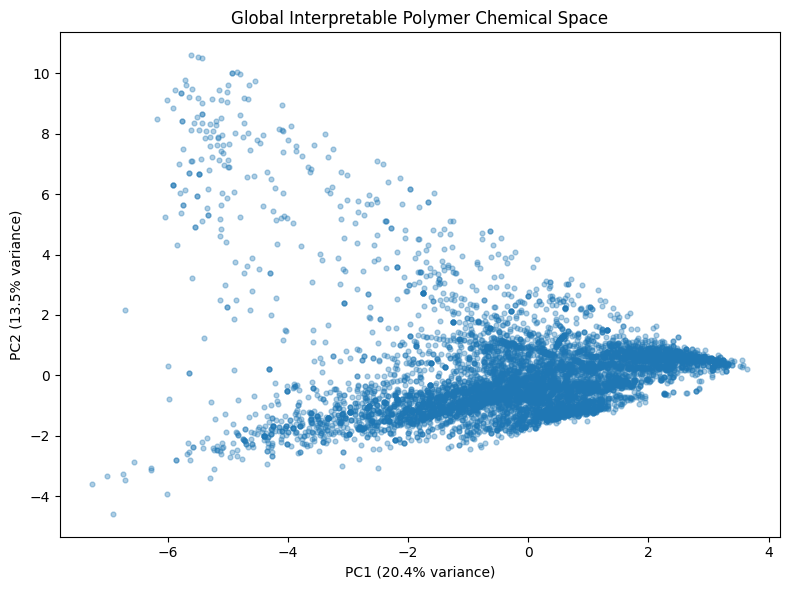

In [45]:
plt.figure(figsize=(8, 6))

plt.scatter(
    train["PC1"],
    train["PC2"],
    s=12,
    alpha=0.35
)

plt.xlabel(
    f"PC1 ({explained_variance[0]:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({explained_variance[1]:.1f}% variance)"
)

plt.title(
    "Global Interpretable Polymer Chemical Space"
)

plt.tight_layout()
plt.show()

### 14.3 Chemical Interpretation of Principal Components

Principal components are mathematical combinations of the original standardized descriptors.

A polymer's position along a principal component is therefore determined by the descriptors that contribute most strongly to that component.

To interpret the chemical-space map, PCA loadings are examined for PC1 and PC2. Large positive or negative loadings identify descriptors that most strongly influence movement along each axis.

The sign of a principal component is mathematically arbitrary; therefore, interpretation focuses on the relative magnitude and direction of descriptor contributions rather than assigning intrinsic meaning to positive or negative signs.

In [46]:
# ============================================================
# PCA descriptor loadings
# ============================================================

loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_features,
    columns=[
        f"PC{i + 1}"
        for i in range(len(pca_features))
    ]
)

print("PCA LOADINGS — PC1 AND PC2")
print("=" * 70)

display(
    loadings[["PC1", "PC2"]]
    .round(4)
)

PCA LOADINGS — PC1 AND PC2


,PC1,PC2
n_heavy_atoms,0.1705,-0.0779
hetero_fraction,-0.4126,0.1720
aromatic_fraction,0.4191,-0.0134
N_fraction,0.0907,-0.0206
O_fraction,-0.3985,-0.3289
S_fraction,-0.0269,0.0714
halogen_fraction,-0.2155,0.5434
ring_density,0.3994,-0.0530
density_carbonyl,-0.3008,-0.3866
density_ester,-0.3128,-0.2118


In [47]:
# ============================================================
# Identify strongest contributors to PC1 and PC2
# ============================================================

for pc in ["PC1", "PC2"]:

    ranked = (
        loadings[[pc]]
        .assign(
            absolute_loading=lambda x:
            x[pc].abs()
        )
        .sort_values(
            "absolute_loading",
            ascending=False
        )
    )

    print(f"\nSTRONGEST CONTRIBUTORS TO {pc}")
    print("=" * 60)

    display(
        ranked.head(10).round(4)
    )


STRONGEST CONTRIBUTORS TO PC1


,PC1,absolute_loading
aromatic_fraction,0.4191,0.4191
hetero_fraction,-0.4126,0.4126
ring_density,0.3994,0.3994
O_fraction,-0.3985,0.3985
density_ester,-0.3128,0.3128
density_carbonyl,-0.3008,0.3008
halogen_fraction,-0.2155,0.2155
density_c_f_bond,-0.2074,0.2074
n_heavy_atoms,0.1705,0.1705
N_fraction,0.0907,0.0907



STRONGEST CONTRIBUTORS TO PC2


,PC2,absolute_loading
halogen_fraction,0.5434,0.5434
density_c_f_bond,0.5359,0.5359
density_carbonyl,-0.3866,0.3866
O_fraction,-0.3289,0.3289
density_amide,-0.2449,0.2449
density_ester,-0.2118,0.2118
hetero_fraction,0.1720,0.1720
n_heavy_atoms,-0.0779,0.0779
density_ether,-0.0738,0.0738
density_c_c_double_bond,0.0720,0.0720


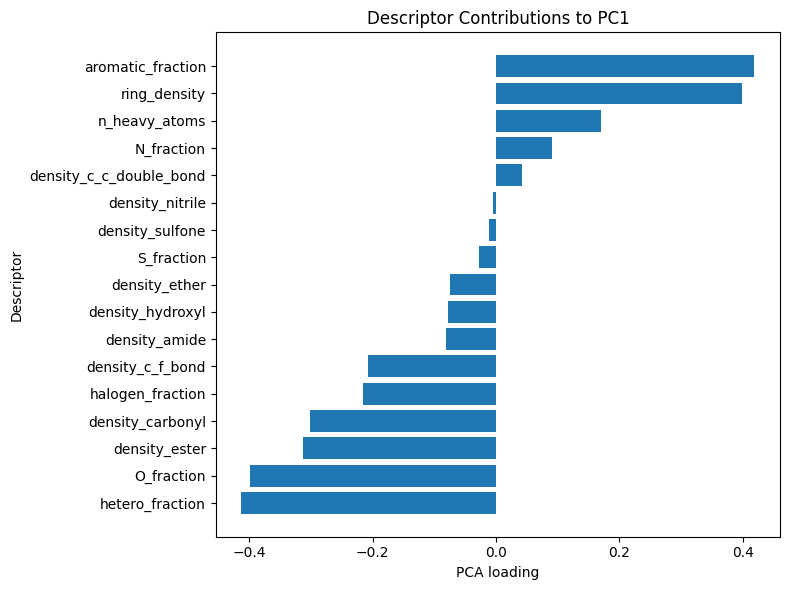

In [48]:
pc1_loadings = (
    loadings["PC1"]
    .sort_values()
)

plt.figure(figsize=(8, 6))

plt.barh(
    pc1_loadings.index,
    pc1_loadings.values
)

plt.xlabel("PCA loading")
plt.ylabel("Descriptor")
plt.title("Descriptor Contributions to PC1")

plt.tight_layout()
plt.show()

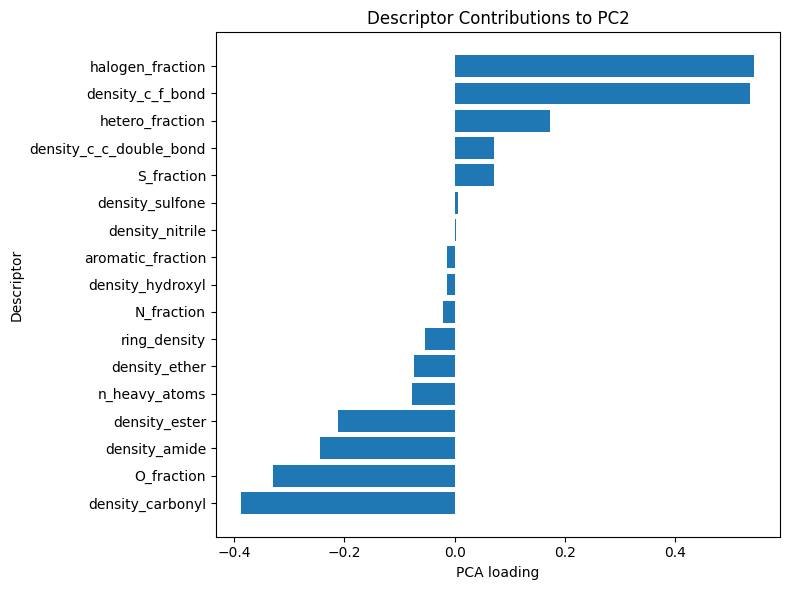

In [49]:
pc2_loadings = (
    loadings["PC2"]
    .sort_values()
)

plt.figure(figsize=(8, 6))

plt.barh(
    pc2_loadings.index,
    pc2_loadings.values
)

plt.xlabel("PCA loading")
plt.ylabel("Descriptor")
plt.title("Descriptor Contributions to PC2")

plt.tight_layout()
plt.show()

### 14.4 Property-Specific Coverage of Polymer Chemical Space

Each property-specific dataset is projected onto the same PCA coordinate system derived from all polymer structures.

The complete polymer dataset provides the structural reference space, while polymers containing measurements for each target are highlighted separately.

This visualization reveals whether individual property datasets broadly sample the available polymer chemical space or are concentrated within particular structural regions.

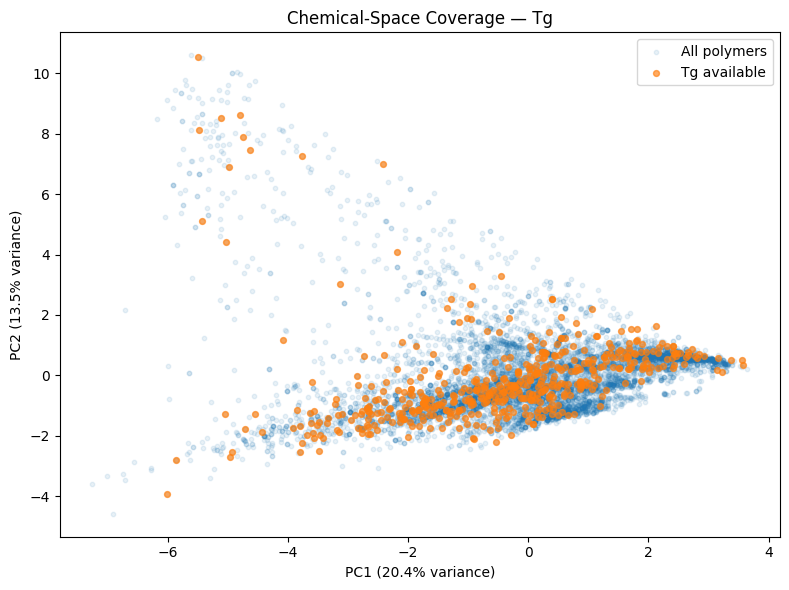

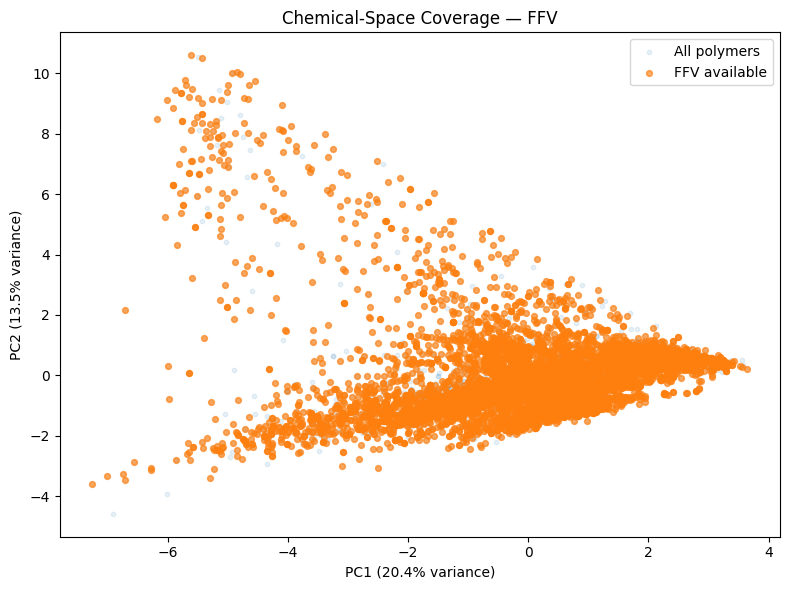

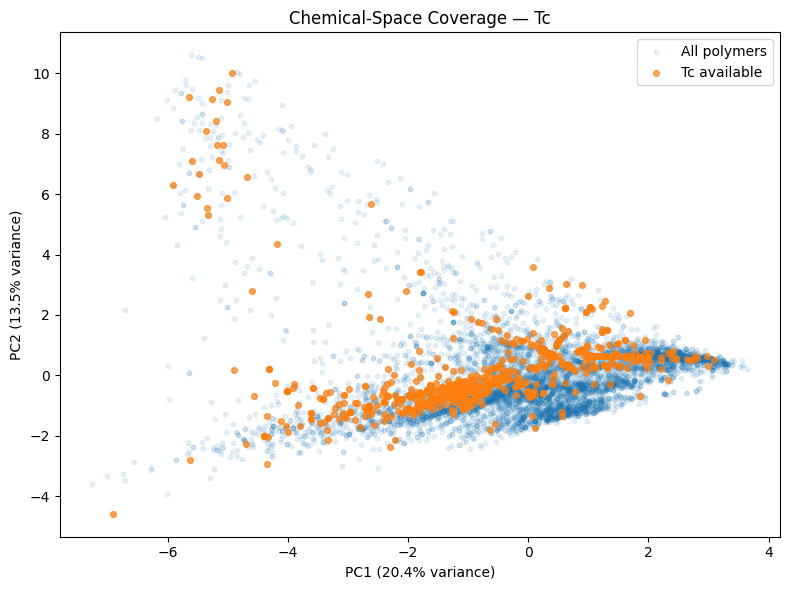

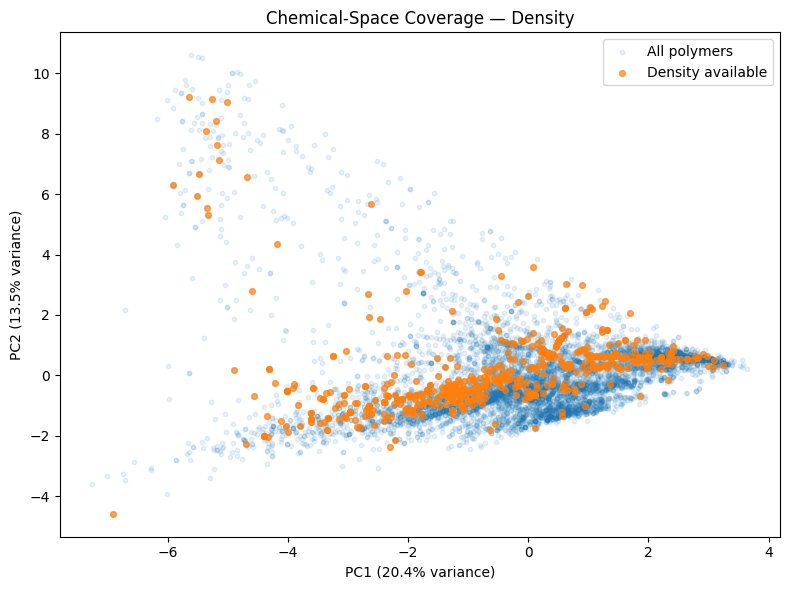

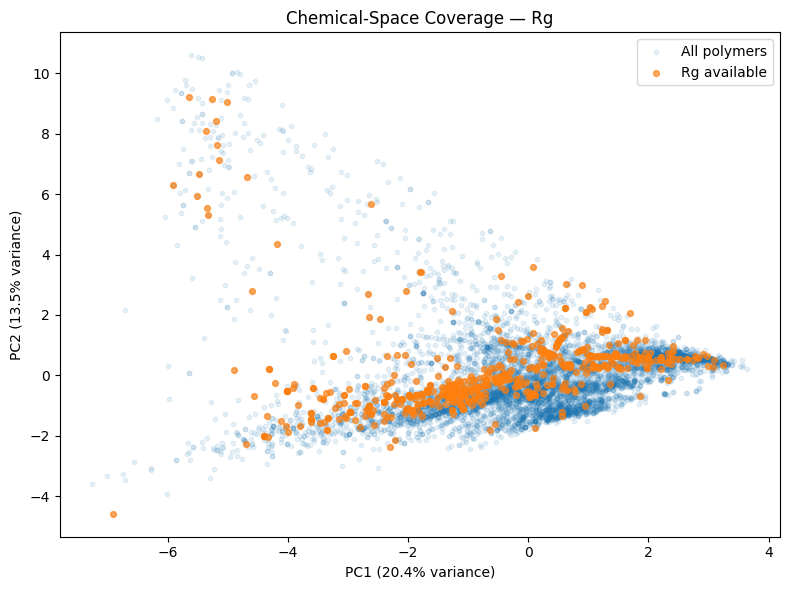

In [50]:
# ============================================================
# Property-specific coverage of the common PCA space
# ============================================================

for target in target_columns:

    subset = train.loc[
        train[target].notna()
    ]

    plt.figure(figsize=(8, 6))

    # All polymers as the reference chemical space
    plt.scatter(
        train["PC1"],
        train["PC2"],
        s=10,
        alpha=0.10,
        label="All polymers"
    )

    # Polymers with this target available
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        s=18,
        alpha=0.65,
        label=f"{target} available"
    )

    plt.xlabel(
        f"PC1 ({explained_variance[0]:.1f}% variance)"
    )

    plt.ylabel(
        f"PC2 ({explained_variance[1]:.1f}% variance)"
    )

    plt.title(
        f"Chemical-Space Coverage — {target}"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

### 14.5 Chemical Validation of PCA Extremes

PCA loadings suggest that the first principal component primarily separates aromatic/ring-rich repeat units from oxygenated and heteroatom-rich structures, while the second principal component is strongly influenced by halogen and carbon–fluorine content.

To verify that these mathematical interpretations correspond to actual polymer chemistry, representative structures from the extremes of PC1 and PC2 are examined.

Extreme-score polymers provide chemically interpretable examples of the structural motifs responsible for the major directions of variation in the Polymer Informatics Atlas.

In [51]:
# ============================================================
# Inspect polymers at the extremes of PC1 and PC2
# ============================================================

extreme_features = [
    "id",
    "SMILES",
    "PC1",
    "PC2",
    "n_heavy_atoms",
    "hetero_fraction",
    "aromatic_fraction",
    "ring_density",
    "O_fraction",
    "halogen_fraction",
    "density_carbonyl",
    "density_ester",
    "density_c_f_bond"
]

print("MOST NEGATIVE PC1 POLYMERS")
print("=" * 70)

display(
    train
    .nsmallest(10, "PC1")[extreme_features]
    .round(4)
)

print("\nMOST POSITIVE PC1 POLYMERS")
print("=" * 70)

display(
    train
    .nlargest(10, "PC1")[extreme_features]
    .round(4)
)

print("\nMOST NEGATIVE PC2 POLYMERS")
print("=" * 70)

display(
    train
    .nsmallest(10, "PC2")[extreme_features]
    .round(4)
)

print("\nMOST POSITIVE PC2 POLYMERS")
print("=" * 70)

display(
    train
    .nlargest(10, "PC2")[extreme_features]
    .round(4)
)

MOST NEGATIVE PC1 POLYMERS


,id,SMILES,PC1,PC2,n_heavy_atoms,hetero_fraction,aromatic_fraction,ring_density,O_fraction,halogen_fraction,density_carbonyl,density_ester,density_c_f_bond
4302,1158783004,*CC(OC=O)C(COC(=O)O*)OC=O,-7.2580,-3.6111,14,0.5000,0.0,0.0000,0.5000,0.0000,0.2143,0.2143,0.0000
7886,2123073246,*CC(*)OC(=O)OC([2H])([2H])[2H],-7.0115,-3.3336,7,0.4286,0.0,0.0000,0.4286,0.0000,0.1429,0.2857,0.0000
631,176911109,*C1C(=O)OC(=O)C1*,-6.9226,-4.5856,7,0.4286,0.0,0.1429,0.4286,0.0000,0.2857,0.2857,0.0000
2368,644108438,*CC(OC(=O)OCC)C(COC(=O)O*)OC(=O)OCC,-6.7512,-3.2547,20,0.4500,0.0,0.0000,0.4500,0.0000,0.1500,0.2500,0.0000
659,183910750,*CC(OC(=O)C(=O)OCC)C(COC(=O)O*)OC(=O)C(=O)OCC,-6.7215,-3.4679,24,0.4583,0.0,0.0000,0.4583,0.0000,0.2083,0.2083,0.0000
3355,917938501,*CC(*)OC(=O)OCC(F)(F)F,-6.7156,2.1576,11,0.5455,0.0,0.0000,0.2727,0.2727,0.0909,0.1818,0.2727
1978,532722806,*CCOC(=O)O*,-6.5647,-2.8782,6,0.5000,0.0,0.0000,0.5000,0.0000,0.1667,0.1667,0.0000
452,125969488,*CC(OC(C)=O)C(COC(=O)O*)OC(C)=O,-6.2882,-3.0780,16,0.4375,0.0,0.0000,0.4375,0.0000,0.1875,0.1875,0.0000
1118,299097300,*C(*)C(=O)OC,-6.2837,-3.1241,5,0.4000,0.0,0.0000,0.4000,0.0000,0.2000,0.2000,0.0000
6838,1853676235,*C(F)(F)C(*)(OC(F)(F)F)OC(F)(F)F,-6.1876,8.4784,14,0.7143,0.0,0.0000,0.1429,0.5714,0.0000,0.0000,0.5714



MOST POSITIVE PC1 POLYMERS


,id,SMILES,PC1,PC2,n_heavy_atoms,hetero_fraction,aromatic_fraction,ring_density,O_fraction,halogen_fraction,density_carbonyl,density_ester,density_c_f_bond
5575,1511995434,*Nc1cccc(-c2cc(-c3ccc(C4(c5ccccc5)c5ccccc5-c5c...,3.6456,0.2098,89,0.0225,0.9438,0.1910,0.0000,0.0,0.0,0.0,0.0
7129,1926476264,*=c1cc2ccc3cc(=c4oc(=*)c5ccc6cccc7c8cccc9ccc4c...,3.5694,0.3520,39,0.0256,1.0000,0.2564,0.0256,0.0,0.0,0.0,0.0
4783,1293239198,*=c1cc2ccc3cc(=c4c5ccccc5c(=*)c5ccccc45)cc4ccc...,3.5536,0.4949,30,0.0000,1.0000,0.2333,0.0000,0.0,0.0,0.0,0.0
4759,1286616307,*c1ccc(C2(c3ccc(-c4cc(-c5ccccc5)c5cc(C6(c7ccc8...,3.5524,0.2900,70,0.0286,0.9714,0.2000,0.0000,0.0,0.0,0.0,0.0
1158,310898724,*Nc1ccc2ccc3c(N*)c(-c4ccc(C5(c6ccccc6)c6ccccc6...,3.5283,0.2958,68,0.0294,0.9412,0.2059,0.0000,0.0,0.0,0.0,0.0
126,37571918,*Nc1cc2ccc3ccc4c(N*)cc5ccc6ccc1c1c6c5c4c3c21,3.4312,0.4772,26,0.0769,0.9231,0.2692,0.0000,0.0,0.0,0.0,0.0
4767,1288612893,*Nc1ccc2c(c1)-c1ccc3c4ccc5c6c(ccc(c7ccc(c1c73)...,3.3926,0.4278,36,0.0556,0.8889,0.2500,0.0000,0.0,0.0,0.0,0.0
1169,313842947,*c1ccc(C2(c3ccc(-c4cc(-c5ccccc5)c5cc(-c6ccc7nc...,3.3837,0.3597,57,0.0351,0.9825,0.1930,0.0000,0.0,0.0,0.0,0.0
6028,1635058755,*c1ccc(-c2ccc(-c3cc(-c4ccccc4)c4cc(C5(c6ccc7nc...,3.3837,0.3597,57,0.0351,0.9825,0.1930,0.0000,0.0,0.0,0.0,0.0
3018,819286039,*c1ccc2nc3c4cccc5c6nc7ccc(*)cc7nc6c6cccc(c3nc2...,3.3668,0.5206,32,0.1250,1.0000,0.2500,0.0000,0.0,0.0,0.0,0.0



MOST NEGATIVE PC2 POLYMERS


,id,SMILES,PC1,PC2,n_heavy_atoms,hetero_fraction,aromatic_fraction,ring_density,O_fraction,halogen_fraction,density_carbonyl,density_ester,density_c_f_bond
631,176911109,*C1C(=O)OC(=O)C1*,-6.9226,-4.5856,7,0.4286,0.0,0.1429,0.4286,0.0,0.2857,0.2857,0.0
4813,1300127001,*CC1(*)CC(=O)OC1=O,-6.0125,-3.9225,8,0.3750,0.0,0.1250,0.3750,0.0,0.2500,0.2500,0.0
4302,1158783004,*CC(OC=O)C(COC(=O)O*)OC=O,-7.2580,-3.6111,14,0.5000,0.0,0.0000,0.5000,0.0,0.2143,0.2143,0.0
659,183910750,*CC(OC(=O)C(=O)OCC)C(COC(=O)O*)OC(=O)C(=O)OCC,-6.7215,-3.4679,24,0.4583,0.0,0.0000,0.4583,0.0,0.2083,0.2083,0.0
4366,1177030933,*CC1CC(*)C(=O)OC1=O,-5.3026,-3.4078,9,0.3333,0.0,0.1111,0.3333,0.0,0.2222,0.2222,0.0
7886,2123073246,*CC(*)OC(=O)OC([2H])([2H])[2H],-7.0115,-3.3336,7,0.4286,0.0,0.0000,0.4286,0.0,0.1429,0.2857,0.0
2368,644108438,*CC(OC(=O)OCC)C(COC(=O)O*)OC(=O)OCC,-6.7512,-3.2547,20,0.4500,0.0,0.0000,0.4500,0.0,0.1500,0.2500,0.0
1118,299097300,*C(*)C(=O)OC,-6.2837,-3.1241,5,0.4000,0.0,0.0000,0.4000,0.0,0.2000,0.2000,0.0
5197,1409830378,*CC(OC)C1C(=O)OC(=O)C1*,-5.2318,-3.0894,11,0.3636,0.0,0.0909,0.3636,0.0,0.1818,0.1818,0.0
452,125969488,*CC(OC(C)=O)C(COC(=O)O*)OC(C)=O,-6.2882,-3.0780,16,0.4375,0.0,0.0000,0.4375,0.0,0.1875,0.1875,0.0



MOST POSITIVE PC2 POLYMERS


,id,SMILES,PC1,PC2,n_heavy_atoms,hetero_fraction,aromatic_fraction,ring_density,O_fraction,halogen_fraction,density_carbonyl,density_ester,density_c_f_bond
6210,1683937350,*C(*)(F)F,-5.6086,10.6034,3,0.6667,0.0,0.0000,0.0000,0.6667,0.0,0.0,0.6667
2938,799217349,*C(F)(F)C(F)(F)C(F)(F)C(*)(F)C(F)(F)F,-5.4947,10.5513,15,0.6667,0.0,0.0000,0.0000,0.6667,0.0,0.0,0.6667
2331,636356107,*C(F)(F)C(*)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F...,-5.4378,10.5253,21,0.6667,0.0,0.0000,0.0000,0.6667,0.0,0.0,0.6667
3463,948991314,*C(F)(F)C1(F)C(F)(F)C(*)(F)C(F)(F)C(F)(F)C(F)(...,-4.8556,10.0333,22,0.6364,0.0,0.0455,0.0000,0.6364,0.0,0.0,0.6364
131,38242048,*/C(F)=C(\F)C(F)(C(*)(F)F)C(F)(F)F,-4.9361,10.0242,13,0.6154,0.0,0.0000,0.0000,0.6154,0.0,0.0,0.6154
5817,1578702981,*C(F)=C(F)C(F)(C(*)(F)F)C(F)(F)F,-4.9361,10.0242,13,0.6154,0.0,0.0000,0.0000,0.6154,0.0,0.0,0.6154
4478,1205844020,*C(F)(F)C1(F)C(F)(F)C(*)(F)C(F)(F)C(F)(F)C1(F)F,-4.7937,9.9694,19,0.6316,0.0,0.0526,0.0000,0.6316,0.0,0.0,0.6316
1558,418211347,*C(F)(F)C(*)(F)OC(F)(F)C(F)(F)C(F)(F)C(F)(F)F,-5.7085,9.7687,19,0.6842,0.0,0.0000,0.0526,0.6316,0.0,0.0,0.6316
4359,1175231244,*C(F)(F)C1(F)C(F)(F)C(*)(F)C1(F)F,-4.5446,9.7348,13,0.6154,0.0,0.0769,0.0000,0.6154,0.0,0.0,0.6154
7450,2014263245,*OC(F)(F)C(F)(F)C(F)(F)C(*)(F)F,-5.7012,9.6202,13,0.6923,0.0,0.0000,0.0769,0.6154,0.0,0.0,0.6154


In [52]:
from rdkit.Chem import Draw

def display_pca_extreme_structures(
    dataframe,
    pc,
    largest=True,
    n=8
):
    if largest:
        selected = dataframe.nlargest(n, pc)
        direction = "High"
    else:
        selected = dataframe.nsmallest(n, pc)
        direction = "Low"

    molecules = [
        Chem.MolFromSmiles(smiles)
        for smiles in selected["SMILES"]
    ]

    legends = [
        f"{pc}={score:.2f}"
        for score in selected[pc]
    ]

    image = Draw.MolsToGridImage(
        molecules,
        molsPerRow=4,
        subImgSize=(300, 220),
        legends=legends
    )

    print(f"{direction} {pc} representative polymers")
    display(image)

Low PC1 representative polymers


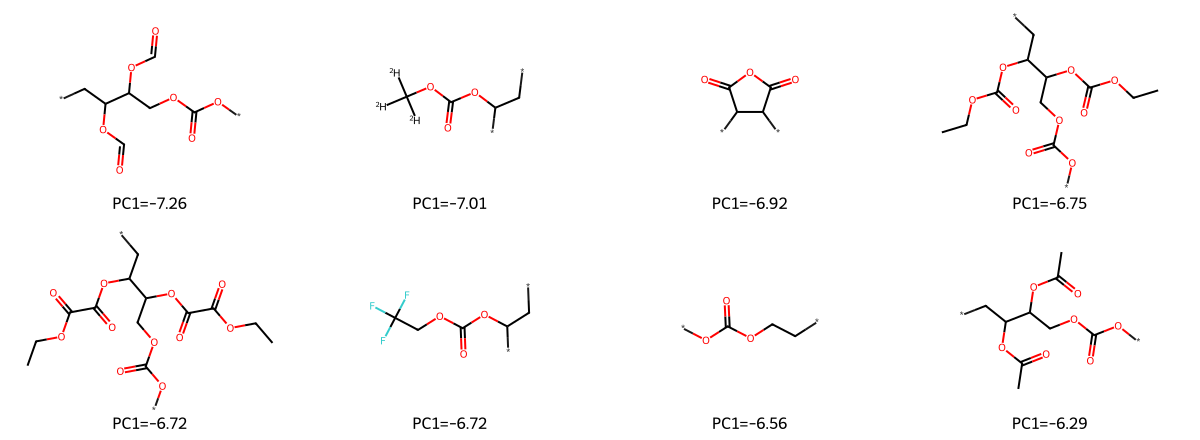

In [53]:
display_pca_extreme_structures(
    train,
    "PC1",
    largest=False
)

High PC1 representative polymers


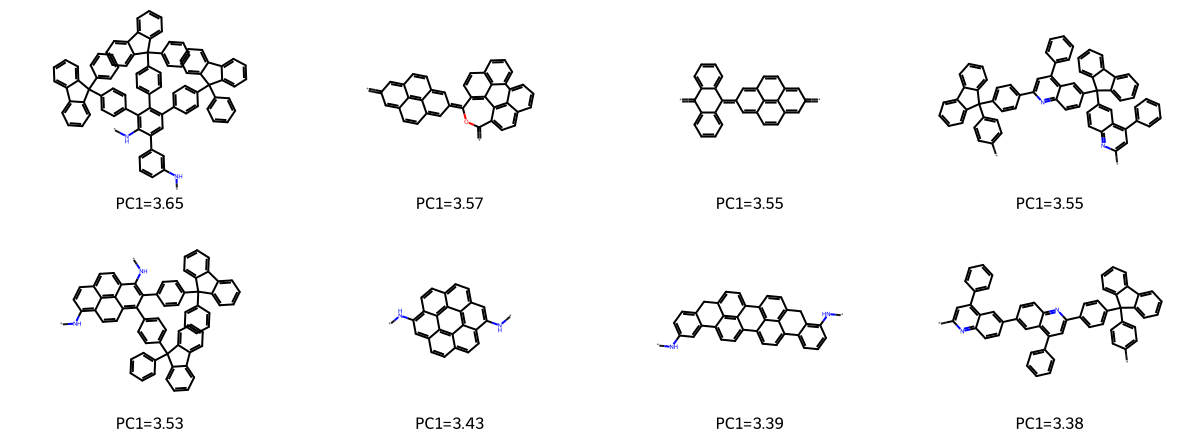

In [54]:
display_pca_extreme_structures(
    train,
    "PC1",
    largest=True
)

Low PC2 representative polymers


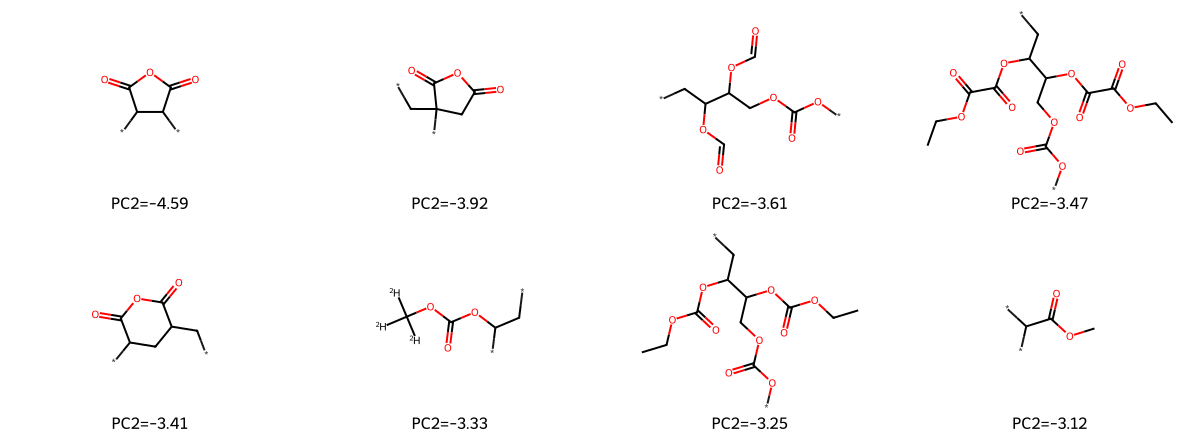

In [55]:
display_pca_extreme_structures(
    train,
    "PC2",
    largest=False
)

High PC2 representative polymers


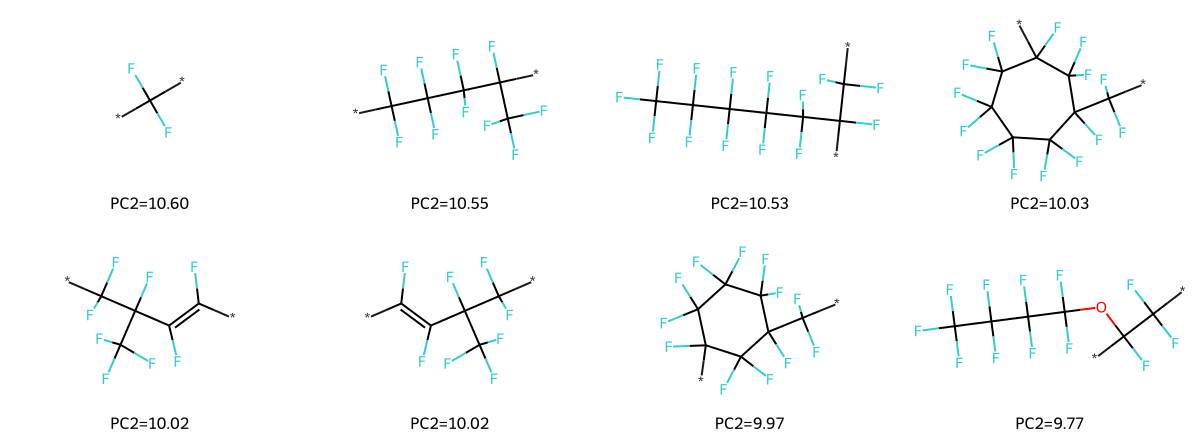

In [56]:
display_pca_extreme_structures(
    train,
    "PC2",
    largest=True
)

## 15. Quantitative Comparison of Property-Specific Chemical Domains

The two-dimensional PCA projection provides an interpretable visualization of polymer chemical space, but the first two principal components represent only 33.90% of the total variance.

The first ten principal components collectively retain approximately 90% of the standardized descriptor variance and therefore provide a more complete representation for quantitative comparison.

Each property-specific polymer dataset is represented by its centroid in this ten-dimensional PCA space.

Pairwise Euclidean distances between these centroids are used as a descriptive measure of chemical-domain separation.

Small centroid distances indicate similar average chemical composition, whereas larger distances indicate stronger shifts in the structural chemistry sampled by different property datasets.

These distances describe dataset composition rather than predictive difficulty.

In [57]:
# ============================================================
# Ten-dimensional PCA representation (~90% variance retained)
# ============================================================

N_PCS_DOMAIN = 10

pc_domain_columns = [
    f"PC{i + 1}_domain"
    for i in range(N_PCS_DOMAIN)
]

for i, column in enumerate(pc_domain_columns):
    train[column] = X_pca_all[:, i]

retained_variance = cumulative_variance[
    N_PCS_DOMAIN - 1
]

print("HIGH-DIMENSIONAL CHEMICAL-SPACE REPRESENTATION")
print("=" * 70)

print(f"Number of PCs retained: {N_PCS_DOMAIN}")

print(
    f"Cumulative variance retained: "
    f"{retained_variance:.2f}%"
)

print(
    f"Coordinate matrix shape: "
    f"{train[pc_domain_columns].shape}"
)

HIGH-DIMENSIONAL CHEMICAL-SPACE REPRESENTATION
Number of PCs retained: 10
Cumulative variance retained: 90.34%
Coordinate matrix shape: (7973, 10)


In [58]:
# ============================================================
# Target-domain centroids in 10D PCA space
# ============================================================

target_centroids = {}

for target in target_columns:

    subset = train.loc[
        train[target].notna(),
        pc_domain_columns
    ]

    target_centroids[target] = (
        subset.mean().to_numpy()
    )


target_centroid_df = pd.DataFrame(
    target_centroids,
    index=pc_domain_columns
).T

print("TARGET-DOMAIN CENTROIDS")
print("=" * 70)

display(
    target_centroid_df.round(3)
)

TARGET-DOMAIN CENTROIDS


,PC1_domain,PC2_domain,PC3_domain,PC4_domain,PC5_domain,PC6_domain,PC7_domain,PC8_domain,PC9_domain,PC10_domain
Tg,-0.505,-0.161,-0.251,0.350,0.154,-0.076,-0.057,0.166,0.003,0.071
FFV,0.076,-0.003,0.099,-0.051,0.008,0.031,0.003,-0.036,-0.014,-0.025
Tc,-0.786,0.129,-1.197,0.346,-0.323,-0.388,-0.026,0.124,0.227,0.310
Density,-0.703,0.092,-1.169,0.249,-0.290,-0.317,-0.018,0.018,0.106,0.268
Rg,-0.698,0.098,-1.181,0.250,-0.293,-0.320,-0.019,0.023,0.109,0.272


In [59]:
from scipy.spatial.distance import euclidean

domain_distance_matrix = pd.DataFrame(
    index=target_columns,
    columns=target_columns,
    dtype=float
)

for target_a in target_columns:
    for target_b in target_columns:

        domain_distance_matrix.loc[
            target_a,
            target_b
        ] = euclidean(
            target_centroids[target_a],
            target_centroids[target_b]
        )

print("PAIRWISE TARGET-DOMAIN CENTROID DISTANCES")
print("=" * 70)

display(
    domain_distance_matrix.round(3)
)

PAIRWISE TARGET-DOMAIN CENTROID DISTANCES


,Tg,FFV,Tc,Density,Rg
Tg,0.000,0.855,1.222,1.133,1.146
FFV,0.855,0.000,1.754,1.621,1.630
Tc,1.222,1.754,0.000,0.229,0.222
Density,1.133,1.621,0.229,0.000,0.017
Rg,1.146,1.630,0.222,0.017,0.000


In [60]:
# ============================================================
# Within-domain chemical-space dispersion
# ============================================================

domain_dispersion = []

for target in target_columns:

    subset = train.loc[
        train[target].notna(),
        pc_domain_columns
    ].to_numpy()

    centroid = target_centroids[target]

    distances_to_centroid = np.linalg.norm(
        subset - centroid,
        axis=1
    )

    domain_dispersion.append({
        "Target": target,
        "n_polymers": len(subset),
        "median_distance_to_centroid":
            np.median(distances_to_centroid),
        "mean_distance_to_centroid":
            np.mean(distances_to_centroid),
        "90th_percentile_distance":
            np.percentile(
                distances_to_centroid,
                90
            )
    })


domain_dispersion = pd.DataFrame(
    domain_dispersion
).set_index("Target")

print("WITHIN-DOMAIN CHEMICAL-SPACE DISPERSION")
print("=" * 70)

display(
    domain_dispersion.round(3)
)

WITHIN-DOMAIN CHEMICAL-SPACE DISPERSION


,n_polymers,median_distance_to_centroid,mean_distance_to_centroid,90th_percentile_distance
Target,,,,
Tg,511,3.062,3.581,5.596
FFV,7030,2.873,3.367,5.393
Tc,737,2.559,3.278,5.561
Density,613,2.703,3.431,5.629
Rg,614,2.689,3.425,5.625


In [61]:
# ============================================================
# Distance of each target domain from global polymer centroid
# ============================================================

global_centroid = train[
    pc_domain_columns
].mean().to_numpy()

global_domain_distances = {}

for target in target_columns:

    global_domain_distances[target] = euclidean(
        target_centroids[target],
        global_centroid
    )


global_domain_distances = pd.Series(
    global_domain_distances,
    name="Distance from global chemical-space centroid"
).sort_values()

print("TARGET-DOMAIN DISTANCE FROM GLOBAL ATLAS CENTRE")
print("=" * 70)

display(
    global_domain_distances
    .round(3)
    .to_frame()
)

TARGET-DOMAIN DISTANCE FROM GLOBAL ATLAS CENTRE


,Distance from global chemical-space centroid
FFV,0.146
Tg,0.729
Density,1.483
Rg,1.493
Tc,1.614


## 16. Final Dataset Consistency Audit

Before the curated Polymer Informatics Atlas dataset is exported for downstream modelling, a final integrity audit is performed.

The purpose of this audit is to ensure that:

- the original number of polymer records has been preserved,
- structural identifiers remain unique,
- canonical polymer representations remain unique,
- no unexpected missing or infinite values were introduced into engineered descriptors,
- target values remain unchanged,
- and all derived chemical-space variables are numerically valid.

The raw target measurements are not modified during Notebook 01.

In [62]:
# ============================================================
# Final Notebook 01 integrity checks
# ============================================================

print("FINAL DATASET CONSISTENCY AUDIT")
print("=" * 70)

print(f"Total polymers:                  {len(train):,}")
print(f"Unique IDs:                      {train['id'].nunique():,}")
print(f"Unique raw SMILES:               {train['SMILES'].nunique():,}")
print(f"Unique canonical SMILES:         {train['canonical_smiles'].nunique():,}")
print(f"RDKit-valid structures:          {train['rdkit_valid'].sum():,}")

# All engineered numeric descriptors used so far
engineered_numeric_columns = (
    pca_features
    + ["PC1", "PC2"]
    + pc_domain_columns
)

n_missing_engineered = (
    train[engineered_numeric_columns]
    .isna()
    .sum()
    .sum()
)

n_infinite_engineered = np.isinf(
    train[engineered_numeric_columns]
    .to_numpy()
).sum()

print(f"Missing engineered values:       {n_missing_engineered:,}")
print(f"Infinite engineered values:      {n_infinite_engineered:,}")

print("\nTARGET COUNTS")
print("-" * 70)

for target in target_columns:
    print(
        f"{target:8s}: "
        f"{train[target].notna().sum():,}"
    )

FINAL DATASET CONSISTENCY AUDIT
Total polymers:                  7,973
Unique IDs:                      7,973
Unique raw SMILES:               7,973
Unique canonical SMILES:         7,973
RDKit-valid structures:          7,973
Missing engineered values:       0
Infinite engineered values:      0

TARGET COUNTS
----------------------------------------------------------------------
Tg      : 511
FFV     : 7,030
Tc      : 737
Density : 613
Rg      : 614


## 17. Curated Atlas Dataset

The audited polymer structures, original property targets, structural metadata, interpretable descriptors, functional-group descriptors, and chemical-space coordinates are consolidated into a curated dataset.

This exported table forms the common data foundation for subsequent notebooks.

Raw target values are retained exactly as provided in the source dataset. Derived columns contain only structural metadata or descriptors generated during the present analysis.

In [63]:
# ============================================================
# Define curated dataset columns
# ============================================================

core_columns = [
    "id",
    "SMILES",
    "canonical_smiles",
    "architecture_class",
    "n_connection_points",
    "connection_bond_types",
    "n_fragments",
    "n_targets_available",
    "target_signature"
]

target_export_columns = [
    "Tg",
    "FFV",
    "Tc",
    "Density",
    "Rg"
]

structural_columns = [
    "n_heavy_atoms",
    "n_explicit_H",
    "n_C",
    "n_N",
    "n_O",
    "n_S",
    "n_halogen",
    "n_hetero",
    "n_aromatic",
    "n_rings",
    "hetero_fraction",
    "aromatic_fraction",
    "carbon_fraction",
    "N_fraction",
    "O_fraction",
    "S_fraction",
    "halogen_fraction",
    "ring_density"
]

functional_columns = (
    fg_columns
    + [
        fg.replace("fg_", "density_")
        for fg in fg_columns
    ]
)

chemical_space_columns = [
    "PC1",
    "PC2"
] + pc_domain_columns

curated_columns = (
    core_columns
    + target_export_columns
    + structural_columns
    + functional_columns
    + chemical_space_columns
)

atlas_curated = train[
    curated_columns
].copy()

print("CURATED ATLAS DATASET")
print("=" * 70)

print(f"Rows:    {atlas_curated.shape[0]:,}")
print(f"Columns: {atlas_curated.shape[1]}")

display(atlas_curated.head())

CURATED ATLAS DATASET
Rows:    7,973
Columns: 62


,id,SMILES,canonical_smiles,architecture_class,n_connection_points,connection_bond_types,n_fragments,n_targets_available,target_signature,Tg,...,PC1_domain,PC2_domain,PC3_domain,PC4_domain,PC5_domain,PC6_domain,PC7_domain,PC8_domain,PC9_domain,PC10_domain
0,87817,*CC(*)c1ccccc1C(=O)OCCCCCC,*CC(*)c1ccccc1C(=O)OCCCCCC,two_connection_points,2,"(SINGLE, SINGLE)",1,2,FFV + Tc,NaN,...,-0.649197,-0.501616,-1.530676,-0.377044,-0.921553,-0.789689,-0.654967,-0.519208,-0.151527,0.062819
1,106919,*Nc1ccc([C@H](CCC)c2ccc(C3(c4ccc([C@@H](CCC)c5...,*Nc1ccc([C@H](CCC)c2ccc(C3(c4ccc([C@@H](CCC)c5...,two_connection_points,2,"(SINGLE, SINGLE)",1,1,FFV,NaN,...,2.058174,0.516462,-0.570184,-0.124404,-0.458523,-0.285411,-0.241132,-0.036293,0.081060,0.372666
2,388772,*Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(C4(c5ccc(Oc6ccc(...,*Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(C4(c5ccc(Oc6ccc(...,two_connection_points,2,"(SINGLE, SINGLE)",1,1,FFV,NaN,...,1.447896,0.028326,0.179972,-2.547085,2.378282,-0.508372,1.605745,0.689843,-1.485056,-0.987873
3,519416,*Nc1ccc(-c2c(-c3ccc(C)cc3)c(-c3ccc(C)cc3)c(N*)...,*Nc1ccc(-c2c(-c3ccc(C)cc3)c(-c3ccc(C)cc3)c(N*)...,two_connection_points,2,"(SINGLE, SINGLE)",1,1,FFV,NaN,...,2.698342,0.489948,-0.226389,-0.328117,-0.404317,-0.210368,-0.453630,-0.347343,-0.094485,0.188064
4,539187,*Oc1ccc(OC(=O)c2cc(OCCCCCCCCCOCC3CCCN3c3ccc([N...,*Oc1ccc(OC(=O)c2cc(OCCCCCCCCCOCC3CCCN3c3ccc([N...,two_connection_points,2,"(SINGLE, SINGLE)",1,1,FFV,NaN,...,-0.047239,-0.409306,0.484767,-1.402313,0.006284,0.966344,0.649818,0.269031,0.718589,0.008530


In [64]:
from pathlib import Path

output_dir = Path("polymer_atlas_outputs")
output_dir.mkdir(
    parents=True,
    exist_ok=True
)

curated_path = (
    output_dir
    / "polymer_atlas_curated.csv"
)

atlas_curated.to_csv(
    curated_path,
    index=False
)

print(
    f"Curated dataset saved to: "
    f"{curated_path}"
)

Curated dataset saved to: polymer_atlas_outputs/polymer_atlas_curated.csv


In [65]:
# ============================================================
# Read-back verification
# ============================================================

atlas_check = pd.read_csv(
    curated_path
)

print("SAVED-FILE VERIFICATION")
print("=" * 70)

print(
    f"Saved shape: "
    f"{atlas_check.shape}"
)

print(
    f"IDs preserved: "
    f"{atlas_check['id'].nunique() == train['id'].nunique()}"
)

print(
    f"SMILES preserved: "
    f"{atlas_check['SMILES'].nunique() == train['SMILES'].nunique()}"
)

print(
    f"Tg count preserved: "
    f"{atlas_check['Tg'].notna().sum() == 511}"
)

print(
    f"FFV count preserved: "
    f"{atlas_check['FFV'].notna().sum() == 7030}"
)

print(
    f"Tc count preserved: "
    f"{atlas_check['Tc'].notna().sum() == 737}"
)

print(
    f"Density count preserved: "
    f"{atlas_check['Density'].notna().sum() == 613}"
)

print(
    f"Rg count preserved: "
    f"{atlas_check['Rg'].notna().sum() == 614}"
)

SAVED-FILE VERIFICATION
Saved shape: (7973, 62)
IDs preserved: True
SMILES preserved: True
Tg count preserved: True
FFV count preserved: True
Tc count preserved: True
Density count preserved: True
Rg count preserved: True


# 18. Notebook 01 — Key Findings and Modelling Decisions

Notebook 01 established the structural and statistical foundation of the Polymer Informatics Atlas.

### Dataset integrity

The core dataset contains 7,973 polymer records. All records have unique identifiers, unique raw SMILES representations, and unique canonicalized polymer structures. All 7,973 polymer SMILES were successfully parsed by RDKit, and every representation consists of a single connected molecular fragment.

The dominant repeat-unit representation contains two polymer connection points, accounting for 7,955 of 7,973 structures. Only 18 structures contain atypical connection-point counts, and all 18 occur within the FFV-labelled subset. These structures were retained rather than removed because unusual polymer representations do not necessarily indicate erroneous chemistry.

### Target-property structure

Property coverage is strongly imbalanced:

- Tg: 511 polymers
- FFV: 7,030 polymers
- Tc: 737 polymers
- Density: 613 polymers
- Rg: 614 polymers

Most polymers contain only one available target. Consequently, global removal of missing target values would destroy most of the useful dataset and is not appropriate.

The property-overlap analysis revealed a strongly connected Tc–Density–Rg block. Density and Rg exhibit 98.87% Jaccard similarity in record membership, while 531 polymers contain Tc, Density, and Rg simultaneously.

Tg and FFV are substantially more independent from this shared block.

### Polymer chemical space

The dataset spans substantial variation in repeat-unit size, heteroatom content, aromaticity, ring content, elemental composition, and functional-group chemistry.

Approximately four-fifths of the dataset contains aromatic atoms and a similarly large fraction contains oxygen. Nitrogen-containing polymers are also common, while sulfur- and halogen-containing polymers form smaller but chemically distinctive regions.

Functional-group analysis identified widespread carbonyl, amide, ether, and ester chemistry together with smaller nitrile, hydroxyl, sulfone, carbon–carbon double-bond, and carbon–fluorine populations.

### Principal-component chemical-space atlas

A 17-descriptor interpretable representation was constructed using repeat-unit size, normalized elemental composition, aromaticity, ring density, and normalized functional-group descriptors.

PC1 explains 20.44% of standardized descriptor variance and primarily separates aromatic/ring-rich polymers from oxygenated, heteroatom-rich, carbonyl- and ester-containing chemistry.

PC2 explains 13.46% and is dominated by halogen fraction and carbon–fluorine density. Inspection of extreme structures confirmed that the high-PC2 branch is strongly enriched in highly fluorinated polymer repeat units.

The first two components explain 33.90% of the total descriptor variance and are therefore used primarily for visualization. The first ten components retain 90.34% of the variance and provide the higher-dimensional representation used for quantitative chemical-domain comparison.

### Property-domain comparison

Tc, Density, and Rg occupy nearly identical polymer chemical domains. Their centroid distances in the ten-dimensional PCA space are very small, particularly Density–Rg (0.017).

FFV occupies a substantially shifted domain relative to Tc, Density, and Rg, while Tg occupies an intermediate but distinct region.

The target-specific domains nevertheless exhibit substantial internal dispersion and overlap. They should therefore be interpreted as shifted, partially overlapping polymer populations rather than completely separated chemical classes.

### Decisions for downstream modelling

The results of Notebook 01 determine the modelling strategy used in subsequent notebooks:

1. Property-specific datasets will be constructed without globally removing missing targets.
2. Tg and FFV will initially be treated as independent prediction tasks.
3. Tc, Density, and Rg will first receive independent baseline models, followed by a controlled investigation of whether their strong record and chemical-domain overlap supports transfer or multitask learning.
4. Polymer structures will not be randomly assumed to constitute independent chemistry during train/test splitting; chemistry-aware generalization tests will be introduced later.
5. Atypical connection-point structures and statistical property extremes will not be removed without chemical or provenance-based justification.
6. The two-dimensional PCA representation will be used for visualization only, while higher-dimensional representations will be preferred for quantitative chemical-space analysis.
7. Increasingly complex machine-learning representations will be compared against interpretable polymer descriptors rather than assumed to be superior in advance.

The curated output of Notebook 01 contains the audited raw targets, canonical structures, structural metadata, interpretable descriptors, functional-group descriptors, and chemical-space coordinates required for subsequent Polymer Informatics Atlas analyses.

In [66]:
from google.colab import files

files.download(
    "polymer_atlas_outputs/polymer_atlas_curated.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>